# Librerías necesarias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from google.colab import drive
from IPython.display import display
drive.mount('/content/drive')
ruta_base = "/content/drive/MyDrive/Proyecto/datasets"

archivo_entrada = os.path.join(
    ruta_base,
    "players_23.csv"
)

chunk_size = 50000

MessageError: Error: credential propagation was unsuccessful

# ACOMODACIÓN DE LOS CSV

In [ ]:
import pandas as pd
import os

ruta_base = "/content/drive/MyDrive/Proyecto/datasets"

archivo = os.path.join(
    ruta_base,
    "players_22.csv"
)

df = pd.read_csv(archivo)

print("Total filas:", len(df))

# Buscar IDs duplicados
duplicados = df[df.duplicated(subset=["sofifa_id"], keep=False)]

print("Cantidad de filas con ID duplicado:", len(duplicados))

# Mostrar solo ID y nombre
resultado = duplicados[["sofifa_id", "short_name"]].sort_values("sofifa_id")

print("\nIDs duplicados y nombre del jugador:")
print(resultado)

Total filas: 19239
Cantidad de filas con ID duplicado: 0

IDs duplicados y nombre del jugador:
Empty DataFrame
Columns: [sofifa_id, short_name]
Index: []


In [ ]:
# Union de datasets 2015 - 2022
# Ruta en Google Drive
ruta = "/content/drive/MyDrive/Proyecto/datasets"

years = range(15, 23)

dataframes = []

for year in years:

    archivo = os.path.join(ruta, f"players_{year}.csv")
    print("Leyendo:", archivo)

    try:
        df = pd.read_csv(
            archivo,
            encoding="utf-8",
            low_memory=False
        )
        print("Encoding usado: utf-8")

    except UnicodeDecodeError:

        df = pd.read_csv(
            archivo,
            encoding="latin1",
            low_memory=False
        )
        print("Encoding usado: latin1")

    # Crear columna season
    season = 2000 + year
    df.insert(0, "season", season)

    dataframes.append(df)

print("Uniendo datasets...")

df_final = pd.concat(dataframes, ignore_index=True)

# Guardar archivo final en Drive
salida = os.path.join(ruta, "players_2015-2022.csv")

df_final.to_csv(
    salida,
    index=False,
    encoding="utf-8-sig"
)

print("Archivo creado correctamente:")
print(salida)
print("Total de filas:", len(df_final))

Leyendo: /content/drive/MyDrive/Proyecto/datasets/players_15.csv
Encoding usado: utf-8
Leyendo: /content/drive/MyDrive/Proyecto/datasets/players_16.csv
Encoding usado: utf-8
Leyendo: /content/drive/MyDrive/Proyecto/datasets/players_17.csv
Encoding usado: utf-8
Leyendo: /content/drive/MyDrive/Proyecto/datasets/players_18.csv
Encoding usado: utf-8
Leyendo: /content/drive/MyDrive/Proyecto/datasets/players_19.csv
Encoding usado: utf-8
Leyendo: /content/drive/MyDrive/Proyecto/datasets/players_20.csv
Encoding usado: utf-8
Leyendo: /content/drive/MyDrive/Proyecto/datasets/players_21.csv
Encoding usado: utf-8
Leyendo: /content/drive/MyDrive/Proyecto/datasets/players_22.csv
Encoding usado: utf-8
Uniendo datasets...
Archivo creado correctamente:
/content/drive/MyDrive/Proyecto/datasets/players_2015-2022.csv
Total de filas: 142079


In [ ]:
# Reduccion de dataset players_2015-2022
# Ruta base en Google Drive
ruta_base = "/content/drive/MyDrive/Proyecto/datasets"

archivo_entrada = os.path.join(
    ruta_base,
    "players_2015-2022.csv"
)

archivo_salida = os.path.join(
    ruta_base,
    "datasets_reduccion",
    "players_2015-2022_reduction.csv"
)

# cargar dataset

print("Cargando dataset...")

df = pd.read_csv(
    archivo_entrada,
    encoding="utf-8",
    low_memory=False
)

print("Filas originales:", len(df))

# Columnas que se quedan

columnas_usar = [
    "season",
    "sofifa_id",
    "short_name",
    "age",
    "nationality_name",
    "club_name",
    "league_name",
    "player_positions",
    "club_position",
    "preferred_foot",
    "height_cm",
    "weight_kg",
    "overall",
    "potential",
    "value_eur",
    "wage_eur",
    "pace",
    "shooting",
    "passing",
    "dribbling",
    "defending",
    "physic"
]

df = df[columnas_usar]

# Renombrar columnas

df = df.rename(columns={
    "season": "Season",
    "sofifa_id": "player_id",
    "nationality_name": "nationality"
})

columnas_finales = [
    "Season",
    "player_id",
    "short_name",
    "age",
    "nationality",
    "club_name",
    "league_name",
    "player_positions",
    "club_position",
    "preferred_foot",
    "height_cm",
    "weight_kg",
    "overall",
    "potential",
    "value_eur",
    "wage_eur",
    "pace",
    "shooting",
    "passing",
    "dribbling",
    "defending",
    "physic"
]

df = df[columnas_finales]

# Guardar CSV (reemplaza si existe)

df.to_csv(
    archivo_salida,
    index=False,
    encoding="utf-8-sig"
)

print("\nCSV limpio creado correctamente")
print("Ruta:", archivo_salida)
print("Filas finales:", len(df))
print("Columnas finales:")

for c in df.columns:
    print(c)

Cargando dataset...
Filas originales: 142079

CSV limpio creado correctamente
Ruta: /content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/players_2015-2022_reduction.csv
Filas finales: 142079
Columnas finales:
Season
player_id
short_name
age
nationality
club_name
league_name
player_positions
club_position
preferred_foot
height_cm
weight_kg
overall
potential
value_eur
wage_eur
pace
shooting
passing
dribbling
defending
physic


In [ ]:
import warnings
warnings.filterwarnings("ignore")
for chunk in pd.read_csv(archivo_entrada, chunksize=chunk_size):

    print("Columnas del dataset:")
    print(chunk.columns)

    print("\nTipos de datos:")
    print(chunk.dtypes)

    break

Columnas del dataset:
Index(['season', 'sofifa_id', 'player_url', 'short_name', 'long_name',
       'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur',
       ...
       'lcb', 'cb', 'rcb', 'rb', 'gk', 'player_face_url', 'club_logo_url',
       'club_flag_url', 'nation_logo_url', 'nation_flag_url'],
      dtype='object', length=111)

Tipos de datos:
season              int64
sofifa_id           int64
player_url         object
short_name         object
long_name          object
                    ...  
player_face_url    object
club_logo_url      object
club_flag_url      object
nation_logo_url    object
nation_flag_url    object
Length: 111, dtype: object


In [ ]:
for chunk in pd.read_csv(archivo_entrada, chunksize=chunk_size):

    display(chunk.head(5))

    break

,season,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined,club_contract_valid_until,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,2015,158023,https://sofifa.com/player/158023/lionel-messi/150002,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,100500000.0,550000.0,27,1987-06-24,169,67,241.0,FC Barcelona,Spain Primera Division,1.0,CF,10.0,NaN,2004-07-01,2018.0,52,Argentina,1369.0,CF,10.0,Left,3,4,5,Medium/Low,Normal (170-),Yes,NaN,"#Speedster, #Dribbler, #FK Specialist, #Acrobat, #Clinical Finisher, #Complete Forward","Finesse Shot, Speed Dribbler (AI), One Club Player, Team Player",93.0,89.0,86.0,96.0,27.0,63.0,84,94,71,89,85,96,89,90,76,96,96,90,94,94,95,80,73,77,60,88,48,22,92,90,76,NaN,25,21,20,6,11,15,14,8,NaN,89+3,89+3,89+3,92+3,90+3,90+3,90+3,92+3,92+3,92+3,92+3,90+3,79+3,79+3,79+3,90+3,62+3,62+3,62+3,62+3,62+3,54+3,45+3,45+3,45+3,54+3,15+3,https://cdn.sofifa.net/players/158/023/15_120.png,https://cdn.sofifa.net/teams/241/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,2015,20801,https://sofifa.com/player/20801/c-ronaldo-dos-santos-aveiro/150002,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,79000000.0,375000.0,29,1985-02-05,185,80,243.0,Real Madrid CF,Spain Primera Division,1.0,LW,7.0,NaN,2009-07-01,2018.0,38,Portugal,1354.0,LW,7.0,Right,4,5,5,High/Low,Normal (185+),Yes,NaN,"#Speedster, #Dribbler, #Distance Shooter, #Acrobat, #Clinical Finisher, #Complete Forward","Power Free-Kick, Flair, Long Shot Taker (AI), Speed Dribbler (AI)",93.0,93.0,81.0,91.0,32.0,79.0,83,95,86,82,87,93,88,79,72,92,91,94,93,90,63,94,94,89,79,93,63,24,91,81,85,NaN,22,31,23,7,11,15,14,11,NaN,91+1,91+1,91+1,89+3,91+1,91+1,91+1,89+3,89+3,89+3,89+3,87+3,77+3,77+3,77+3,87+3,63+3,63+3,63+3,63+3,63+3,57+3,52+3,52+3,52+3,57+3,16+3,https://cdn.sofifa.net/players/020/801/15_120.png,https://cdn.sofifa.net/teams/243/60.png,https://cdn.sofifa.net/flags/es.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
2,2015,9014,https://sofifa.com/player/9014/arjen-robben/150002,A. Robben,Arjen Robben,"RM, LM, RW",90,90,54500000.0,275000.0,30,1984-01-23,180,80,21.0,FC Bayern München,German 1. Bundesliga,1.0,SUB,10.0,NaN,2009-08-28,2017.0,34,Netherlands,105035.0,RS,11.0,Left,2,4,5,High/Low,Normal (170-185),Yes,NaN,"#Speedster, #Dribbler, #Distance Shooter, #Acrobat","Diver, Injury Prone, Avoids Using Weaker Foot, Selfish, Long Shot Taker (AI), Speed Dribbler (AI), Chip Shot (AI)",93.0,86.0,83.0,92.0,32.0,64.0,80,85,50,86,86,93,85,83,76,90,93,93,93,89,91,86,61,78,65,90,47,39,89,84,80,NaN,29,26,26,10,8,11,5,15,NaN,84+3,84+3,84+3,88+2,87+3,87+3,87+3,88+2,88+2,88+2,88+2,87+3,78+3,78+3,78+3,87+3,64+3,64+3,6

In [ ]:
total_filas = 0

for chunk in pd.read_csv(archivo_entrada, chunksize=chunk_size):
    total_filas += len(chunk)

print("Total de filas:", total_filas)

Total de filas: 10003590


In [ ]:
nulos_totales = None

for chunk in pd.read_csv(archivo_entrada, chunksize=chunk_size):

    nulos = chunk.isnull().sum()

    if nulos_totales is None:
        nulos_totales = nulos
    else:
        nulos_totales += nulos

print("Valores nulos por columna:")
print(nulos_totales.sort_values(ascending=False))

Valores nulos por columna:
nation_team_id          9410000
nation_position         9410000
nation_jersey_number    9410000
club_loaned_from        9299422
player_tags             9238676
                         ...   
cb                            0
rcb                           0
rb                            0
gk                            0
player_face_url               0
Length: 110, dtype: int64


In [ ]:
porcentaje_nulos = (nulos_totales / total_filas) * 100

print(porcentaje_nulos.sort_values(ascending=False))

nation_team_id          94.066230
nation_position         94.066230
nation_jersey_number    94.066230
club_loaned_from        92.960847
player_tags             92.353605
                          ...    
cb                       0.000000
rcb                      0.000000
rb                       0.000000
gk                       0.000000
player_face_url          0.000000
Length: 110, dtype: float64


In [ ]:
duplicados_exactos = 0

for chunk in pd.read_csv(archivo_entrada, chunksize=chunk_size):

    duplicados_exactos += chunk.duplicated().sum()

print("Duplicados exactos:", duplicados_exactos)

Duplicados exactos: 0


In [ ]:
conteo_jugadores = {}

for chunk in pd.read_csv(archivo_entrada, chunksize=chunk_size):

    conteo = chunk["player_id"].value_counts()

    for jugador, cantidad in conteo.items():
        conteo_jugadores[jugador] = conteo_jugadores.get(jugador,0) + cantidad

repetidos = [k for k,v in conteo_jugadores.items() if v > 1]

print("Jugadores con múltiples registros:", len(repetidos))

Jugadores con múltiples registros: 55498


In [ ]:
updates = {}

for chunk in pd.read_csv(archivo_entrada, chunksize=chunk_size):

    grupo = chunk.groupby(["player_id","fifa_version"])["fifa_update"].nunique()

    for key, value in grupo.items():
        if value > 1:
            updates[key] = value

print("Jugadores con updates:", len(updates))

Jugadores con updates: 189612


In [ ]:
edad_min = 100
edad_max = 0

for chunk in pd.read_csv(archivo_entrada, chunksize=chunk_size):

    edad_min = min(edad_min, chunk["age"].min())
    edad_max = max(edad_max, chunk["age"].max())

print("Edad mínima:", edad_min)
print("Edad máxima:", edad_max)

Edad mínima: 15
Edad máxima: 55


In [ ]:
valor_max = 0

for chunk in pd.read_csv(archivo_entrada, chunksize=chunk_size):

    valor_max = max(valor_max, chunk["value_eur"].max())

print("Valor máximo jugador:", valor_max)

Valor máximo jugador: 194000000.0


In [ ]:
nacionalidades = {}

for chunk in pd.read_csv(archivo_entrada, chunksize=chunk_size):

    conteo = chunk["nationality_name"].value_counts()

    for pais, cantidad in conteo.items():
        nacionalidades[pais] = nacionalidades.get(pais,0) + cantidad

print("Número de nacionalidades:", len(nacionalidades))

Número de nacionalidades: 193


In [ ]:
import pandas as pd
import os
import warnings

# ocultar warnings de pandas
warnings.filterwarnings("ignore")

ruta_base = "/content/drive/MyDrive/Proyecto/datasets"

archivo_entrada = os.path.join(
    ruta_base,
    "players_23.csv"
)

archivo_salida = os.path.join(
    ruta_base,
    "players_23_last_update.csv"
)

chunk_size = 50000

print("Iniciando procesamiento...")

if os.path.exists(archivo_salida):
    os.remove(archivo_salida)

latest_player = {}

# 1: detectar última actualización

lector = pd.read_csv(
    archivo_entrada,
    usecols=[
        "player_id",
        "fifa_version",
        "fifa_update",
        "fifa_update_date"
    ],
    parse_dates=["fifa_update_date"],
    date_format="%d/%m/%Y",
    chunksize=chunk_size,
    low_memory=False
)

for chunk in lector:

    for row in chunk.itertuples(index=False):

        pid = row.player_id

        clave = (
            row.fifa_version,
            row.fifa_update,
            row.fifa_update_date
        )

        if pid not in latest_player or clave > latest_player[pid]:
            latest_player[pid] = clave

print("Jugadores analizados:", len(latest_player))


# 2: filtrar dataset

print("Filtrando registros finales...")

primer_chunk = True

lector = pd.read_csv(
    archivo_entrada,
    parse_dates=["fifa_update_date"],
    date_format="%d/%m/%Y",
    chunksize=chunk_size,
    low_memory=False
)

for chunk in lector:

    claves = list(zip(
        chunk["fifa_version"],
        chunk["fifa_update"],
        chunk["fifa_update_date"]
    ))

    mask = [
        latest_player.get(pid) == clave
        for pid, clave in zip(chunk["player_id"], claves)
    ]

    chunk_filtrado = chunk[mask]

    chunk_filtrado.to_csv(
        archivo_salida,
        mode="a",
        index=False,
        header=primer_chunk,
        encoding="utf-8-sig"
    )

    primer_chunk = False


print("Proceso finalizado")
print("Archivo generado:", archivo_salida)

Iniciando procesamiento...
Jugadores analizados: 56880
Filtrando registros finales...
Proceso finalizado
Archivo generado: /content/drive/MyDrive/Proyecto/datasets/players_23_last_update.csv


In [ ]:
# Reduccion del dataset players_2023
import pandas as pd
import os

ruta_base = "/content/drive/MyDrive/Proyecto/datasets"

archivo_entrada = os.path.join(
    ruta_base,
    "players_23_last_update.csv"
)

archivo_salida = os.path.join(
    ruta_base,
    "datasets_reduccion",
    "players_2023_reduction.csv"
)

columnas_usar = [
    "player_id",
    "short_name",
    "age",
    "nationality_name",
    "club_name",
    "league_name",
    "player_positions",
    "club_position",
    "preferred_foot",
    "height_cm",
    "weight_kg",
    "overall",
    "potential",
    "value_eur",
    "wage_eur",
    "pace",
    "shooting",
    "passing",
    "dribbling",
    "defending",
    "physic"
]

chunk_size = 50000

print("Procesando archivo 2023...")

if os.path.exists(archivo_salida):
    os.remove(archivo_salida)

primer_chunk = True

lector = pd.read_csv(
    archivo_entrada,
    usecols=columnas_usar,
    chunksize=chunk_size,
    encoding="utf-8",
    low_memory=False
)

for chunk in lector:

    chunk.insert(0, "Season", 2023)

    chunk = chunk.rename(columns={
        "nationality_name": "nationality"
    })

    chunk.to_csv(
        archivo_salida,
        mode="a",
        index=False,
        header=primer_chunk,
        encoding="utf-8-sig"
    )

    primer_chunk = False

print("Archivo reducido 2023 creado correctamente")
print("Ruta:", archivo_salida)

Procesando archivo 2023...
Archivo reducido 2023 creado correctamente
Ruta: /content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/players_2023_reduction.csv


In [ ]:
import pandas as pd

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# No cortar el ancho de columnas
pd.set_option('display.max_colwidth', None)

archivo = "/content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/players_2023_reduction.csv"

df = pd.read_csv(archivo, nrows=5)

display(df)

,Season,player_id,short_name,player_positions,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_name,club_name,club_position,nationality,preferred_foot,pace,shooting,passing,dribbling,defending,physic
0,2023,158023,L. Messi,RW,91,91,54000000.0,195000.0,35,169,67,Ligue 1,Paris Saint Germain,RS,Argentina,Left,81.0,89.0,90.0,94.0,34.0,64.0
1,2023,165153,K. Benzema,"CF, ST",91,91,64000000.0,450000.0,34,185,81,La Liga,Real Madrid,CF,France,Right,80.0,88.0,83.0,87.0,39.0,78.0
2,2023,188545,R. Lewandowski,ST,91,91,84000000.0,420000.0,33,185,81,La Liga,FC Barcelona,ST,Poland,Right,75.0,91.0,79.0,86.0,44.0,83.0
3,2023,192985,K. De Bruyne,"CM, CAM",91,91,107500000.0,350000.0,31,181,75,Premier League,Manchester City,RCM,Belgium,Right,74.0,88.0,93.0,87.0,63.0,77.0
4,2023,231747,K. Mbappé,"ST, LW",91,95,190500000.0,230000.0,23,182,73,Ligue 1,Paris Saint Germain,LS,France,Right,97.0,89.0,80.0,92.0,36.0,76.0


In [ ]:
import pandas as pd
import numpy as np
import os

# Reducción del dataset players_2024
ruta_base = "/content/drive/MyDrive/Proyecto/datasets"

archivo_entrada = os.path.join(
    ruta_base,
    "players_24.csv"
)

archivo_salida = os.path.join(
    ruta_base,
    "datasets_reduccion",
    "players_2024_reduction.csv"
)

print("Leyendo dataset 2024...")

df = pd.read_csv(
    archivo_entrada,
    encoding="utf-8",
    low_memory=False
)

# -------- EXTRAER PLAYER_ID DESDE URL --------

df["player_id"] = (
    df["URL"]
    .str.extract(r'(\d+)$')   # extrae números al final de la URL
    .astype("Int64")
)

# mover player_id al inicio
cols = ["player_id"] + [c for c in df.columns if c != "player_id"]
df = df[cols]

# -------- RENOMBRAR COLUMNAS --------

df = df.rename(columns={
    "Name": "short_name",
    "Nation": "nationality",
    "Club": "club_name",
    "Position": "player_positions",
    "Age": "age",
    "Overall": "overall",
    "Pace": "pace",
    "Shooting": "shooting",
    "Passing": "passing",
    "Dribbling": "dribbling",
    "Defending": "defending",
    "Physicality": "physic",
    "Preferred foot": "preferred_foot"
})

# -------- COLUMNAS FALTANTES --------

df["Season"] = 2024
df["league_name"] = np.nan
df["club_position"] = df["player_positions"]
df["height_cm"] = np.nan
df["weight_kg"] = np.nan
df["potential"] = np.nan
df["value_eur"] = np.nan
df["wage_eur"] = np.nan

# -------- ORDEN FINAL --------

df_final = df[
[
"Season",
"player_id",
"short_name",
"age",
"nationality",
"club_name",
"league_name",
"player_positions",
"club_position",
"preferred_foot",
"height_cm",
"weight_kg",
"overall",
"potential",
"value_eur",
"wage_eur",
"pace",
"shooting",
"passing",
"dribbling",
"defending",
"physic"
]
]

# -------- GUARDAR DATASET --------

df_final.to_csv(
    archivo_salida,
    index=False,
    encoding="utf-8-sig"
)

print("Archivo limpio 2024 creado correctamente")
print("Ruta:", archivo_salida)
print("Total filas:", len(df_final))

Leyendo dataset 2024...
Archivo limpio 2024 creado correctamente
Ruta: /content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/players_2024_reduction.csv
Total filas: 15845


In [ ]:
# Union de los 3 datasets

ruta = "/content/drive/MyDrive/Proyecto/datasets/datasets_reduccion"

archivo1 = os.path.join(ruta,"players_2015-2022_reduction.csv")
archivo2 = os.path.join(ruta,"players_2023_reduction.csv")
archivo3 = os.path.join(ruta,"players_2024_reduction.csv")

salida = os.path.join(ruta,"datasets_normalizar","players_dataset_final.csv")

print("Cargando datasets...")

df1 = pd.read_csv(archivo1,low_memory=False)
df2 = pd.read_csv(archivo2,low_memory=False)
df3 = pd.read_csv(archivo3,low_memory=False)

print("Uniendo datasets...")

df_union = pd.concat(
    [df1,df2,df3],
    ignore_index=True
)

df_union.to_csv(
    salida,
    index=False,
    encoding="utf-8-sig"
)

print("Union creada")
print("Archivo:",salida)
print("Filas:",len(df_union))

Cargando datasets...
Uniendo datasets...
Union creada
Archivo: /content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar/players_dataset_final.csv
Filas: 214804


# Código para pobar los nuevos IDs para verificar el jugador por año.

In [ ]:
ruta = "/content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar"

archivo = os.path.join(ruta, "players_dataset_final.csv")

print("Cargando dataset final...\n")

df = pd.read_csv(
    archivo,
    usecols=["Season","player_id","short_name"],
    encoding="utf-8",
    low_memory=False
)

player_id = 20289

df_filtrado = df[df["player_id"] == player_id]
df_filtrado = df_filtrado.sort_values("Season")
df_filtrado = df_filtrado.groupby("Season").first().reset_index()

print(f"Historial del jugador ID {player_id}:\n")

for _, row in df_filtrado.iterrows():
    print(f"{row['Season']} -> {row['short_name']} (ID {row['player_id']})")

Cargando dataset final...

Historial del jugador ID 20289:

2015 -> Y. Touré (ID 20289)
2016 -> Y. Touré (ID 20289)
2017 -> Y. Touré (ID 20289)
2018 -> Y. Touré (ID 20289)
2023 -> Y. Touré (ID 20289)


In [ ]:
import os
import pandas as pd

ruta_drive = "/content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar"
archivo = os.path.join(ruta_drive, "players_dataset_final.csv")

print("Cargando dataset final...\n")
df = pd.read_csv(archivo, dtype=str, encoding="utf-8", low_memory=False)

# Crear mapping player_id -> short_name histórico 2015-2023
mask_hist = df['Season'].astype(int) < 2024
historico = df[mask_hist].copy()

# Para cada player_id tomar el short_name más frecuente/histórico
short_map = historico.groupby('player_id')['short_name'].first().to_dict()

# Aplicar al 2024
mask_2024 = df['Season'].astype(int) == 2024
df_2024 = df[mask_2024].copy()

# Reemplazar short_name por el histórico si existe
df.loc[mask_2024, 'short_name'] = df_2024['player_id'].map(short_map).combine_first(df_2024['short_name'])

# Guardar CSV final reemplazando el original
df.to_csv(archivo, index=False, encoding="utf-8-sig")
print(f"Archivo actualizado guardado en: {archivo}")

Cargando dataset final...

Archivo actualizado guardado en: /content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar/players_dataset_final.csv


In [ ]:
import pandas as pd
import os

ruta = "/content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar"
archivo = os.path.join(ruta, "players_dataset_final.csv")

print("Cargando dataset...")

df = pd.read_csv(
    archivo,
    usecols=["player_id","Season"]
)

print("Filas totales:", len(df))

duplicados = df[df.duplicated(
    subset=["player_id","Season"],
    keep=False
)]

print("Filas duplicadas jugador-temporada (año):", len(duplicados))

if len(duplicados) > 0:
    print("\nEjemplos:")
    print(duplicados.sort_values(["player_id","Season"]).head(20))
else:
    print("\nNo hay duplicados por jugador y temporada")

Cargando dataset...
Filas totales: 214804
Filas duplicadas jugador-temporada (año): 0

No hay duplicados por jugador y temporada


In [ ]:
import pandas as pd
import os

ruta = "/content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar"
archivo = os.path.join(ruta, "players_dataset_final.csv")

df = pd.read_csv(archivo)

print("Filas totales:", len(df))

# crear tabla con datos de 2023
datos_2023 = df[df["Season"] == 2023][[
    "player_id",
    "height_cm",
    "weight_kg",
    "league_name"
]]

datos_2023 = datos_2023.set_index("player_id")

# recorrer filas de 2024
for i in df.index:

    if df.loc[i, "Season"] == 2024:

        pid = df.loc[i, "player_id"]

        if pid in datos_2023.index:

            if pd.isna(df.loc[i, "height_cm"]):
                df.loc[i, "height_cm"] = datos_2023.loc[pid, "height_cm"]

            if pd.isna(df.loc[i, "weight_kg"]):
                df.loc[i, "weight_kg"] = datos_2023.loc[pid, "weight_kg"]

            if pd.isna(df.loc[i, "league_name"]):
                df.loc[i, "league_name"] = datos_2023.loc[pid, "league_name"]

# guardar archivo actualizado
df.to_csv(archivo, index=False)

print("Datos copiados desde 2023 hacia 2024 correctamente")

Filas totales: 214804
Datos copiados desde 2023 hacia 2024 correctamente


In [ ]:
import pandas as pd
import os

ruta = "/content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar"
archivo = os.path.join(ruta, "players_dataset_final.csv")

df = pd.read_csv(archivo)

# tabla con short_name del 2023
shortname_2023 = df[df["Season"] == 2023][["player_id", "short_name"]]
shortname_2023 = shortname_2023.set_index("player_id")

# recorrer jugadores de 2024
for i in df.index:

    if df.loc[i, "Season"] == 2024:

        pid = df.loc[i, "player_id"]

        if pid in shortname_2023.index:
            df.loc[i, "short_name"] = shortname_2023.loc[pid, "short_name"]

# guardar cambios
df.to_csv(archivo, index=False)

print("Short_name del 2024 igualado con el de 2023 cuando existe")

Short_name del 2024 igualado con el de 2023 cuando existe


# Ver al estructura dentro del drive mi Proyecto

In [ ]:
def imprimir_arbol(ruta, prefijo=""):
    elementos = sorted(os.listdir(ruta))

    for i, elemento in enumerate(elementos):
        ruta_completa = os.path.join(ruta, elemento)

        if i == len(elementos) - 1:
            conector = "└ "
            nuevo_prefijo = prefijo + "   "
        else:
            conector = "├ "
            nuevo_prefijo = prefijo + "│  "

        print(prefijo + conector + elemento)

        if os.path.isdir(ruta_completa):
            imprimir_arbol(ruta_completa, nuevo_prefijo)


# Ruta de la carpeta Proyecto en Drive
ruta_proyecto = "/content/drive/MyDrive/Proyecto"

print("MyDrive")
print(" └ Proyecto")

imprimir_arbol(ruta_proyecto, "   ")

MyDrive
 └ Proyecto
   ├ dataset_after_supuesto_limpieza
   │  ├ players_2015-2024_dataset_imputado.csv
   │  └ players_2015-2024_dataset_semi_clean.csv
   ├ datasets
   │  ├ datasets_reduccion
   │  │  ├ datasets_normalizar
   │  │  │  ├ players_dataset_final.csv
   │  │  │  └ players_dataset_final_imputado.csv
   │  │  ├ players_2015-2022_reduction.csv
   │  │  ├ players_2015-2024_union.csv
   │  │  ├ players_2023_reduction.csv
   │  │  └ players_2024_reduction.csv
   │  ├ players_15.csv
   │  ├ players_16.csv
   │  ├ players_17.csv
   │  ├ players_18.csv
   │  ├ players_19.csv
   │  ├ players_20.csv
   │  ├ players_2015-2022.csv
   │  ├ players_21.csv
   │  ├ players_22.csv
   │  ├ players_23.csv
   │  ├ players_23_last_update.csv
   │  └ players_24.csv
   └ players_2015-2024_dataset_final.csv


# LA NORMALIZACIÓN DE NOMBRES DE CLUBES (CLUBES CON NOMBRES ESCRITOS LIGERAMENTE DIFERENTE ENTRE BASES DE DATOS, EJ: Paris Saint German, PSG) SE ENCUENTRA AL FINAL DEL NOTEBOOK, YA QUE SE CORRIGIO SOBRE EL ARCHIVO FINAL GENERADO

# Carga de datos


In [ ]:
# FALTA HACER MÁS DE ESTA BOMBA
ruta = "/content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar"

archivo = os.path.join(ruta, "players_dataset_final.csv")

print("Cargando dataset...\n")

df = pd.read_csv(
    archivo,
    nrows=5,
    low_memory=False
)

display(df)

Cargando dataset...



,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic
0,2015,158023,L. Messi,27,Argentina,FC Barcelona,Spain Primera Division,CF,CF,Left,169.00,67.00,93,95.00,100500000.00,550000.00,93.00,89.00,86.00,96.00,27.00,63.00
1,2015,20801,Cristiano Ronaldo,29,Portugal,Real Madrid CF,Spain Primera Division,"LW, LM",LW,Right,185.00,80.00,92,92.00,79000000.00,375000.00,93.00,93.00,81.00,91.00,32.00,79.00
2,2015,9014,A. Robben,30,Netherlands,FC Bayern München,German 1. Bundesliga,"RM, LM, RW",SUB,Left,180.00,80.00,90,90.00,54500000.00,275000.00,93.00,86.00,83.00,92.00,32.00,64.00
3,2015,41236,Z. Ibrahimović,32,Sweden,Paris Saint-Germain,French Ligue 1,ST,ST,Right,195.00,95.00,90,90.00,52500000.00,275000.00,76.00,91.00,81.00,86.00,34.00,86.00
4,2015,167495,M. Neuer,28,Germany,FC Bayern München,German 1. Bundesliga,GK,GK,Right,193.00,92.00,90,90.00,63500000.00,300000.00,NaN,NaN,NaN,NaN,NaN,NaN


#Data dictionary detallado con rangos razonables, unidades y tipado recomendado.

In [ ]:
# ── Montar Google Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Leer el Data Dictionary directo desde Drive ───────────────────────────────
import pandas as pd
from IPython.display import display

FONDO  = '#0d0f1a'
PANEL  = '#13152a'
AZUL_C = '#00c8ff'
VERDE  = '#00e676'
NARANJA= '#ff9100'
ROJO   = '#ff3d57'
TEXTO  = '#e0e0f0'
TEXTO2 = '#a0a0c0'

RUTA = '/content/drive/MyDrive/Proyecto/DataDictionary(2).xlsx'
dd = pd.read_excel(RUTA, sheet_name='Data Dictionary')

# ── Detectar filas de sección (ej. "▸  IDENTIFICADORES") ─────────────────────
def es_seccion(val):
    return isinstance(val, str) and val.strip().startswith('▸')

def estilo_fila(row):
    if es_seccion(row['Variable Estandarizada']):
        return [f'background-color:{AZUL_C}22; color:{AZUL_C}; font-weight:bold; border-top:1px solid {AZUL_C}44'] * len(row)
    return [f'background-color:{PANEL}; color:{TEXTO}'] * len(row)

styled = (
    dd.style
    .apply(estilo_fila, axis=1)
    .set_table_styles([
        {'selector': 'thead th',
         'props': f'background-color:{FONDO}; color:{AZUL_C}; font-weight:bold; '
                  f'font-size:11px; text-transform:uppercase; letter-spacing:0.08em; '
                  f'border-bottom:2px solid {AZUL_C}; padding:8px 12px; text-align:left;'},
        {'selector': 'td',
         'props': f'padding:6px 12px; font-size:12px; border-bottom:1px solid #ffffff0d;'},
        {'selector': 'table',
         'props': f'border-collapse:collapse; width:100%; font-family:monospace; '
                  f'background-color:{FONDO}; border-radius:8px; overflow:hidden;'},
        {'selector': 'tbody tr:hover td',
         'props': f'background-color:{AZUL_C}11 !important;'},
    ])
    .set_properties(**{'white-space': 'pre-wrap', 'max-width': '320px'})
    .hide(axis='index')
    .set_caption(
        f'<span style="color:{AZUL_C}; font-size:14px; font-weight:bold; font-family:monospace;">'
        f'📋 Data Dictionary · players_2015-2024 · {len(dd)} variables</span>'
    )
)

pd.set_option('display.max_rows', None)
display(styled)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Variable Estandarizada,Otros Nombres,Descripción,Tipo Recomendado,Unidad,Rango Razonable,Presente en años
▸ IDENTIFICADORES,nan,nan,nan,nan,nan,nan
row_index,-,Índice o posición del registro en el dataset,int,-,0 - N (número de filas),2024
player_id,sofifa_id,Identificador único del jugador en la base de datos SoFIFA,int,-,positivo,2015-2023
short_name,Name,Nombre corto del jugador,string,-,texto,2015-2024
long_name,-,Nombre completo del jugador,string,-,texto,2015-2023
player_url,URL / player_url,Enlace a la ficha del jugador en SoFIFA,string,URL,enlace web,2015-2024
player_face_url,-,URL de la imagen de la cara del jugador,string,URL,enlace web,2015-2023
nationality_name,Nation / nationality,Nacionalidad del jugador,category,-,nombres de países,2015-2024
nationality_id,-,Identificador numérico de la nacionalidad,int,-,positivo,2015-2023
▸ SELECCIÓN NACIONAL,nan,nan,nan,nan,nan,nan


# Informe de Calidad de Datos


*   Porcentaje de nulos
*   Duplicados
*   Inconsistencias de formato
*   Supuestos de limpieza




In [ ]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# Tema visual oscuro
plt.rcParams.update({
    'figure.facecolor':  '#1a1a2e',
    'axes.facecolor':    '#16213e',
    'axes.edgecolor':    '#0f3460',
    'axes.labelcolor':   '#e0e0e0',
    'axes.titlecolor':   '#ffffff',
    'xtick.color':       '#a0a0a0',
    'ytick.color':       '#a0a0a0',
    'text.color':        '#e0e0e0',
    'grid.color':        '#0f3460',
    'grid.alpha':        0.4,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

# Paleta de colores
VERDE    = '#a8e063'
AZUL_C   = '#53d8fb'
AZUL_O   = '#2176ae'
ROJO     = '#e05c65'
NARANJA  = '#f0a500'
GRIS     = '#4a4a6a'
FONDO    = '#1a1a2e'
PANEL    = '#16213e'

print('Librerías cargadas y tema visual configurado.')

Librerías cargadas y tema visual configurado.


# Resumen General de los Datos


In [ ]:
archivo = "/content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar/players_dataset_final.csv"
df = pd.read_csv(archivo, low_memory=False)


total_filas    = len(df)
total_cols     = len(df.columns)
total_celdas   = df.size
total_nulos    = df.isnull().sum().sum()
total_duplic   = df.duplicated().sum()
pct_nulos      = round(total_nulos / total_celdas * 100, 2)
pct_duplic     = round(total_duplic / total_filas * 100, 2)

resumen = pd.DataFrame({
    'Métrica': [
        'Total de filas',
        'Total de columnas',
        'Total de celdas',
        'Celdas nulas',
        'Filas duplicadas exactas',
        '% de nulos global',
        '% de duplicados global',
    ],
    'Valor': [
        f'{total_filas:,}',
        f'{total_cols:,}',
        f'{total_celdas:,}',
        f'{total_nulos:,}',
        f'{total_duplic:,}',
        f'{pct_nulos} %',
        f'{pct_duplic} %',
    ]
})

print('=' * 45)
print('       RESUMEN GENERAL DEL DATASET')
print('=' * 45)
print(resumen.to_string(index=False))
print('=' * 45)

       RESUMEN GENERAL DEL DATASET
                 Métrica     Valor
          Total de filas   214,804
       Total de columnas        22
         Total de celdas 4,725,688
            Celdas nulas   197,766
Filas duplicadas exactas         0
       % de nulos global    4.18 %
  % de duplicados global     0.0 %


# Tipos de Datos e Inconsistencia de Formato

In [ ]:
# Tipos de datos
reporte_tipos = pd.DataFrame({
    'columna':   df.columns,
    'tipo_dato': df.dtypes.values,
    'ejemplo':   [df[c].dropna().iloc[0] if df[c].notna().any() else 'N/A' for c in df.columns]
})

print('TIPOS DE DATOS EN EL DATASET')
print('─' * 40)
display(reporte_tipos)

# Resumen
tipo_counts = df.dtypes.value_counts().rename_axis('tipo').reset_index(name='cantidad')
print('\nResumen:')
display(tipo_counts)

# Detección de inconsistencias de formato
patrones = {
    'Símbolo € (euros)':        r'€',
    'Sufijo K (miles)':         r'\d+[Kk]\b',
    'Sufijo M (millones)':      r'\d+[Mm]\b',
    'Símbolo $ (dólares)':      r'\$',
    'Símbolo % (porcentaje)':   r'%',
    'Valores mixtos (num+txt)': r'^[\d.,]+[A-Za-z]+$|^[A-Za-z]+[\d.,]+$',
}

resultados_formato = []
for col in df.select_dtypes(include='object').columns:
    muestra = df[col].dropna().astype(str)
    for desc, patron in patrones.items():
        hits = muestra.str.contains(patron, regex=True).sum()
        if hits > 0:
            resultados_formato.append({
                'columna':         col,
                'inconsistencia':  desc,
                'registros_afect': hits,
                '% columna':       round(hits / len(df) * 100, 2)
            })

df_formato = pd.DataFrame(resultados_formato).sort_values('registros_afect', ascending=False) \
    if resultados_formato else pd.DataFrame()

print('\nINCONSISTENCIAS DE FORMATO DETECTADAS')
print('─' * 60)
display(df_formato) if resultados_formato else print('Sin inconsistencias detectadas.')

TIPOS DE DATOS EN EL DATASET
────────────────────────────────────────


,columna,tipo_dato,ejemplo
0,Season,int64,2015
1,player_id,int64,158023
2,short_name,object,L. Messi
3,age,int64,27
4,nationality,object,Argentina
5,club_name,object,FC Barcelona
6,league_name,object,Spain Primera Division
7,player_positions,object,CF
8,club_position,object,CF
9,preferred_foot,object,Left



Resumen:


,tipo,cantidad
0,float64,11
1,object,7
2,int64,4



INCONSISTENCIAS DE FORMATO DETECTADAS
────────────────────────────────────────────────────────────
Sin inconsistencias detectadas.


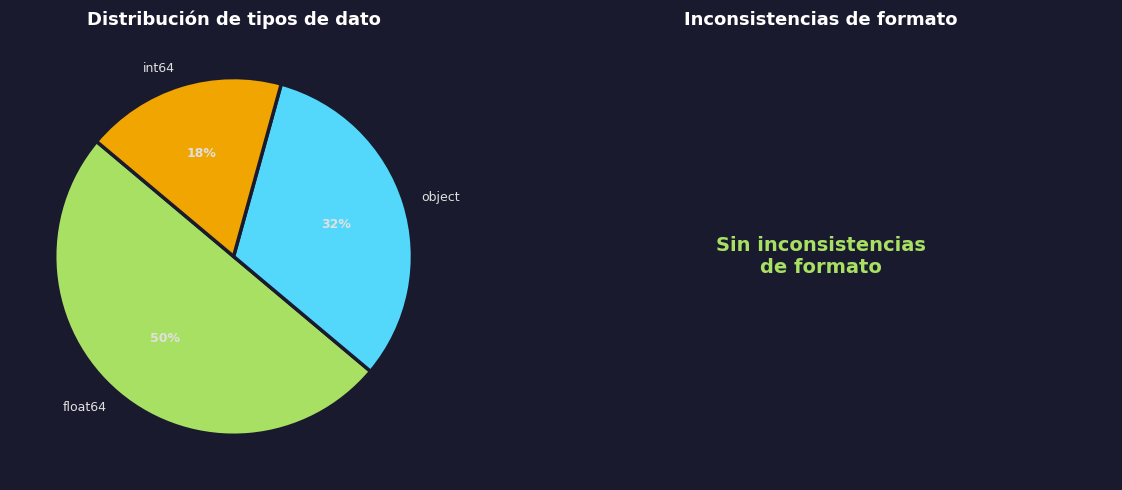

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(FONDO)

# Pie de tipos
ax = axes[0]
ax.set_facecolor(FONDO)
pal = [VERDE, AZUL_C, NARANJA, ROJO, AZUL_O, GRIS]
wedges, _, autotexts = ax.pie(
    tipo_counts['cantidad'],
    labels=tipo_counts['tipo'],
    autopct='%1.0f%%',
    colors=pal[:len(tipo_counts)],
    startangle=140,
    wedgeprops={'edgecolor': FONDO, 'linewidth': 2.5},
    textprops={'color': '#e0e0e0', 'fontsize': 9}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Distribución de tipos de dato', fontsize=13, fontweight='bold')

# Barra de inconsistencias
ax2 = axes[1]
ax2.set_facecolor(PANEL)
if resultados_formato:
    top_incons = df_formato.head(10)
    ax2.barh(
        top_incons['columna'] + ' — ' + top_incons['inconsistencia'].str[:20],
        top_incons['registros_afect'],
        color=NARANJA, height=0.5, edgecolor='none'
    )
    ax2.set_title('Top inconsistencias de formato', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Registros afectados')
    ax2.xaxis.grid(True, alpha=0.3)
    ax2.set_axisbelow(True)
else:
    ax2.text(0.5, 0.5, 'Sin inconsistencias\nde formato', ha='center', va='center',
             fontsize=14, fontweight='bold', color=VERDE, transform=ax2.transAxes)
    ax2.set_title('Inconsistencias de formato', fontsize=13, fontweight='bold')
    ax2.axis('off')

plt.tight_layout()
plt.show()

# Nulos

In [ ]:
#Tabla completa de nulos
nulos            = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
no_nulos         = df.notnull().sum()
tipos            = df.dtypes

reporte_nulos = pd.DataFrame({
    'columna':           df.columns,
    'tipo_dato':         tipos.values,
    'no_nulos':          no_nulos.values,
    'nulos':             nulos.values,
    'porcentaje_nulos':  porcentaje_nulos.round(2).values,
    'estado':            ['Crítico' if p > 50 else 'Moderado' if p > 10 else 'Aceptable'
                          for p in porcentaje_nulos.values]
})

reporte_nulos = reporte_nulos.sort_values('porcentaje_nulos', ascending=False).reset_index(drop=True)

print('\nREPORTE DE NULOS POR COLUMNA')
print('─' * 75)
display(reporte_nulos)


REPORTE DE NULOS POR COLUMNA
───────────────────────────────────────────────────────────────────────────


,columna,tipo_dato,no_nulos,nulos,porcentaje_nulos,estado
0,shooting,float64,192545,22259,10.36,Moderado
1,pace,float64,192545,22259,10.36,Moderado
2,defending,float64,192545,22259,10.36,Moderado
3,physic,float64,192545,22259,10.36,Moderado
4,dribbling,float64,192545,22259,10.36,Moderado
5,passing,float64,192545,22259,10.36,Moderado
6,value_eur,float64,196095,18709,8.71,Aceptable
7,wage_eur,float64,196545,18259,8.50,Aceptable
8,potential,float64,198959,15845,7.38,Aceptable
9,league_name,object,210977,3827,1.78,Aceptable


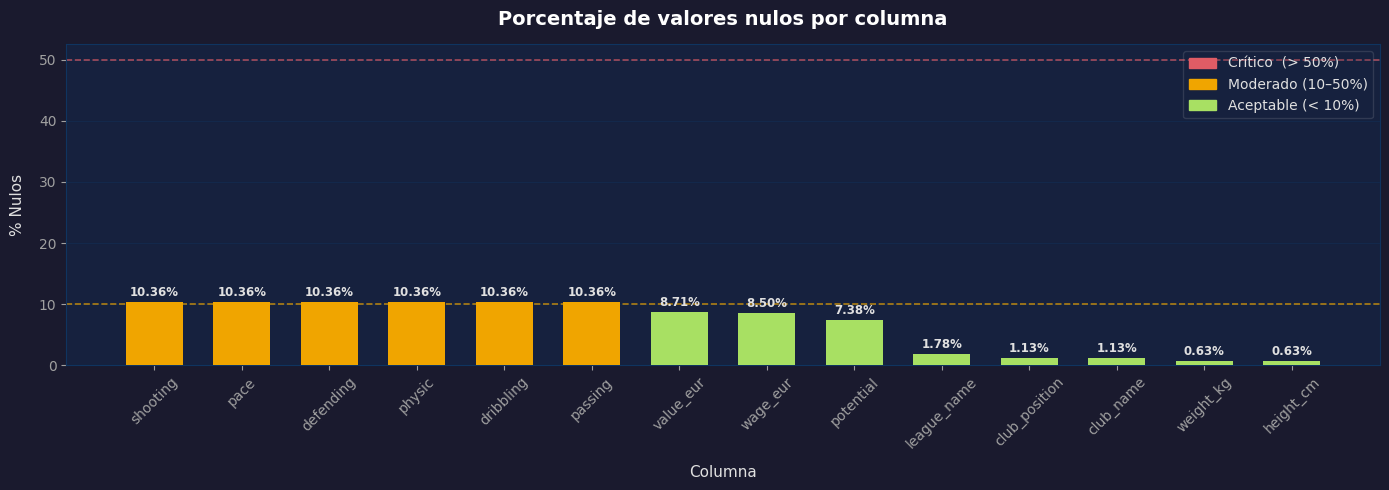

In [ ]:
#Gráfico de barras: columnas con nulos
df_con_nulos = reporte_nulos[reporte_nulos['porcentaje_nulos'] > 0].copy()

if df_con_nulos.empty:
    print('No hay columnas con valores nulos.')
else:
    colores_barra = [
        ROJO if p > 50 else NARANJA if p > 10 else VERDE
        for p in df_con_nulos['porcentaje_nulos']
    ]

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor(FONDO)
    ax.set_facecolor(PANEL)

    bars = ax.bar(
        df_con_nulos['columna'],
        df_con_nulos['porcentaje_nulos'],
        color=colores_barra,
        width=0.65,
        edgecolor='none',
        zorder=3
    )

    # Etiquetas encima de cada barra
    for bar, val in zip(bars, df_con_nulos['porcentaje_nulos']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.2f}%',
            ha='center', va='bottom',
            fontsize=8.5, color='#e0e0e0', fontweight='bold'
        )

    ax.axhline(50, color=ROJO,    linestyle='--', linewidth=1.2, alpha=0.7, label='Umbral crítico (50%)')
    ax.axhline(10, color=NARANJA, linestyle='--', linewidth=1.2, alpha=0.7, label='Umbral moderado (10%)')

    ax.set_title('Porcentaje de valores nulos por columna', fontsize=14, fontweight='bold', pad=14)
    ax.set_ylabel('% Nulos', labelpad=10)
    ax.set_xlabel('Columna', labelpad=10)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)

    legend_patches = [
        mpatches.Patch(color=ROJO,    label='Crítico  (> 50%)'),
        mpatches.Patch(color=NARANJA, label='Moderado (10–50%)'),
        mpatches.Patch(color=VERDE,   label='Aceptable (< 10%)'),
    ]
    ax.legend(handles=legend_patches, loc='upper right', framealpha=0.15, labelcolor='#e0e0e0')

    plt.tight_layout()
    plt.show()

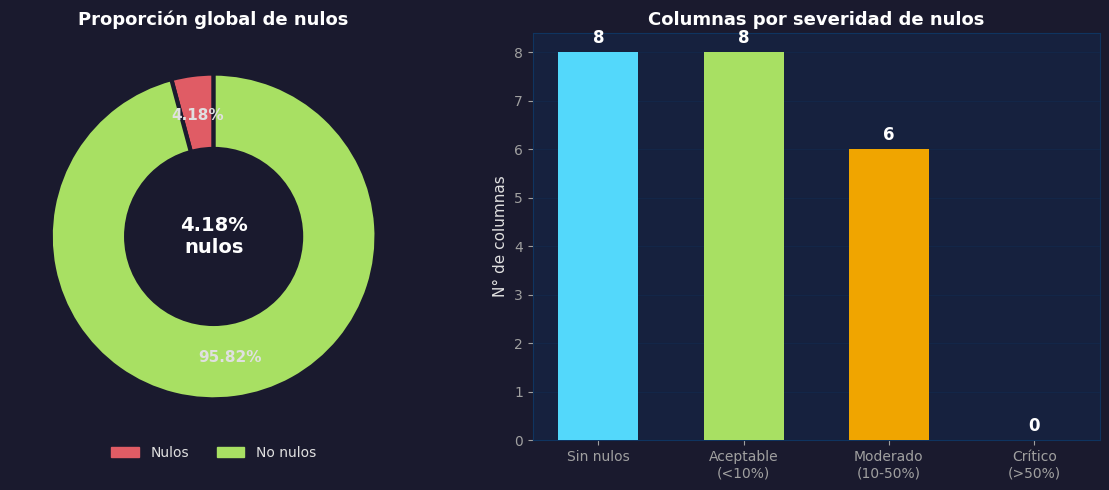

In [ ]:
# Donut: proporción global de nulos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(FONDO)

# Variables globales de nulos
total_celdas = df.size
total_nulos  = df.isnull().sum().sum()
pct_nulos    = round((total_nulos / total_celdas) * 100, 2)

# Donut global
ax = axes[0]
ax.set_facecolor(FONDO)
vals   = [total_nulos, total_celdas - total_nulos]
colors = [ROJO, VERDE]
wedges, _, autotexts = ax.pie(
    vals, autopct='%1.2f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': FONDO, 'linewidth': 3},
    pctdistance=0.75
)
# Donut hole
centre_circle = plt.Circle((0, 0), 0.55, fc=FONDO)
ax.add_artist(centre_circle)
ax.text(0, 0, f'{pct_nulos}%\nnulos', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#ffffff')
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax.legend(
    handles=[mpatches.Patch(color=ROJO, label='Nulos'),
             mpatches.Patch(color=VERDE, label='No nulos')],
    loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=2,
    fontsize=10, framealpha=0, labelcolor='#e0e0e0'
)
ax.set_title('Proporción global de nulos', fontsize=13, fontweight='bold')
ax.annotate(f'Total celdas: {total_celdas:,}  |  Nulos: {total_nulos:,}',
            xy=(0, -1.4), ha='center', fontsize=8.5, color='#a0a0a0')

# Distribución de columnas por severidad
ax2 = axes[1]
ax2.set_facecolor(PANEL)
criticas   = (reporte_nulos['porcentaje_nulos'] > 50).sum()
moderadas  = ((reporte_nulos['porcentaje_nulos'] > 10) & (reporte_nulos['porcentaje_nulos'] <= 50)).sum()
aceptables = ((reporte_nulos['porcentaje_nulos'] > 0)  & (reporte_nulos['porcentaje_nulos'] <= 10)).sum()
sin_nulos  = (reporte_nulos['porcentaje_nulos'] == 0).sum()

cats   = ['Sin nulos', 'Aceptable\n(<10%)', 'Moderado\n(10-50%)', 'Crítico\n(>50%)']
counts = [sin_nulos, aceptables, moderadas, criticas]
cols2  = [AZUL_C, VERDE, NARANJA, ROJO]

b = ax2.bar(cats, counts, color=cols2, width=0.55, edgecolor='none', zorder=3)
for bar, v in zip(b, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(v), ha='center', va='bottom', fontsize=12, fontweight='bold', color='#ffffff')
ax2.yaxis.grid(True, zorder=0, alpha=0.3)
ax2.set_axisbelow(True)
ax2.set_title('Columnas por severidad de nulos', fontsize=13, fontweight='bold')
ax2.set_ylabel('N° de columnas')

plt.tight_layout()
plt.show()

# DUPLICADOS


*   Ver duplicados antes de eliminarlos
*   Verificar que si sean duplicados



In [ ]:
# Análisis de duplicados
dup_total = df.duplicated().sum()
pct_dup   = round(dup_total / len(df) * 100, 2)
impacto   = 'Alto' if pct_dup > 5 else ('Medio' if pct_dup > 1 else 'Bajo')

resumen_dup = pd.DataFrame({
    'Criterio':     ['Fila completa'],
    'Duplicados':   [dup_total],
    '% del dataset': [pct_dup],
    'Impacto':      [impacto]
})

print('\nANÁLISIS DE DUPLICADOS')
print('─' * 45)
display(resumen_dup)


ANÁLISIS DE DUPLICADOS
─────────────────────────────────────────────


,Criterio,Duplicados,% del dataset,Impacto
0,Fila completa,0,0.00,Bajo


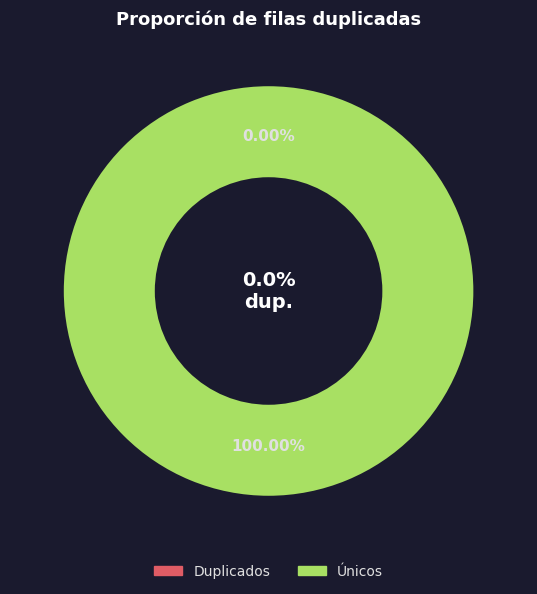

In [ ]:
# Visualización de duplicados
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor(FONDO)
ax.set_facecolor(FONDO)

vals   = [dup_total, len(df) - dup_total]
colors = [ROJO, VERDE]

wedges, _, autotexts = ax.pie(
    vals, autopct='%1.2f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': FONDO, 'linewidth': 3},
    pctdistance=0.75
)
centre_circle = plt.Circle((0, 0), 0.55, fc=FONDO)
ax.add_artist(centre_circle)
ax.text(0, 0, f'{pct_dup}%\ndup.', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#ffffff')
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')

ax.legend(
    handles=[mpatches.Patch(color=ROJO,  label='Duplicados'),
             mpatches.Patch(color=VERDE, label='Únicos')],
    loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=2,
    fontsize=10, framealpha=0, labelcolor='#e0e0e0'
)
ax.set_title('Proporción de filas duplicadas', fontsize=13, fontweight='bold')
ax.annotate(f'Total filas: {len(df):,}  |  Duplicadas: {dup_total:,}',
            xy=(0, -1.4), ha='center', fontsize=8.5, color='#a0a0a0')

plt.tight_layout()
plt.show()

# Detección de Símbolos

In [ ]:
#Detección de símbolos €, K, M en columnas object
cols_object = df.select_dtypes(include='object').columns.tolist()

patrones = {
    'Símbolo € (euros)':       r'€',
    'Sufijo K (miles)':        r'\d+[Kk]\b',
    'Sufijo M (millones)':     r'\d+[Mm]\b',
    'Símbolo $ (dólares)':     r'\$',
    'Símbolo % (porcentaje)':  r'%',
    'Valores mixtos (num+txt)': r'^[\d.,]+[A-Za-z]+$|^[A-Za-z]+[\d.,]+$',
}

resultados_formato = []
for col in cols_object:
    muestra = df[col].dropna().astype(str)
    for desc, patron in patrones.items():
        hits = muestra.str.contains(patron, regex=True).sum()
        if hits > 0:
            resultados_formato.append({
                'columna':          col,
                'inconsistencia':   desc,
                'registros_afect':  hits,
                '% columna':        round(hits / len(df) * 100, 2)
            })

if resultados_formato:
    df_formato = pd.DataFrame(resultados_formato).sort_values('registros_afect', ascending=False)
    print('INCONSISTENCIAS DE FORMATO DETECTADAS')
    print('─' * 60)
    display(df_formato)
else:
    print('No se detectaron inconsistencias de formato (€, K, M, $, %) en columnas de texto.')

No se detectaron inconsistencias de formato (€, K, M, $, %) en columnas de texto.


# CARDINALIDAD DE COLUMNAS CATEGÓRICAS

Se analiza la cantidad de valores únicos en columnas categóricas
clave para identificar posibles problemas de inconsistencia,
alta cardinalidad o necesidad de normalización previo a la
limpieza del dataset.


In [ ]:
# Cardinalidad de columnas categóricas clave
cat_cols = [c for c in ['nationality', 'club_name', 'league_name',
                         'player_positions', 'club_position', 'preferred_foot']
            if c in df.columns]

reporte_cat = pd.DataFrame([{
    'columna':        col,
    'valores_unicos': df[col].nunique()
} for col in cat_cols])

print('CARDINALIDAD DE COLUMNAS CATEGÓRICAS')
print('─' * 50)
display(reporte_cat)

CARDINALIDAD DE COLUMNAS CATEGÓRICAS
──────────────────────────────────────────────────


,columna,valores_unicos
0,nationality,198
1,club_name,1833
2,league_name,101
3,player_positions,2068
4,club_position,29
5,preferred_foot,2


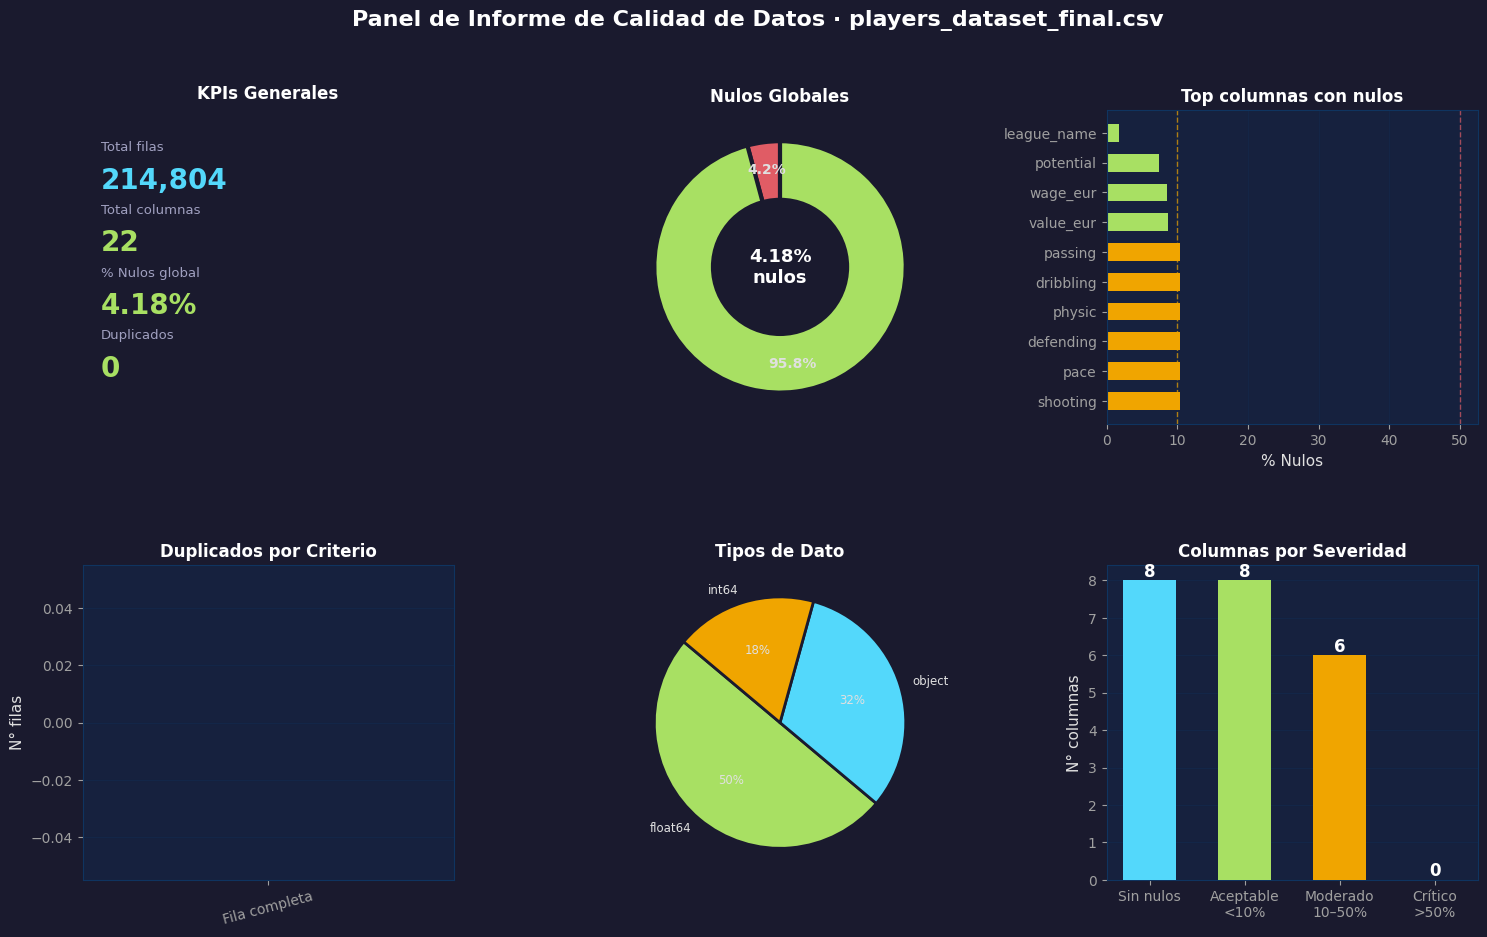

In [ ]:
#Resumen
fig = plt.figure(figsize=(18, 10), facecolor=FONDO)
fig.suptitle(
    'Panel de Informe de Calidad de Datos · players_dataset_final.csv',
    fontsize=16, fontweight='bold', color='white', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax_kpi = fig.add_subplot(gs[0, 0])
ax_kpi.set_facecolor(PANEL)
ax_kpi.axis('off')

kpis = [
    ('Total filas',        f'{total_filas:,}',    AZUL_C,  0.82),
    ('Total columnas',     f'{total_cols:,}',      VERDE,   0.62),
    ('% Nulos global',     f'{pct_nulos}%',        ROJO if pct_nulos > 20 else NARANJA if pct_nulos > 5 else VERDE, 0.42),
    ('Duplicados',         f'{dup_total:,}',       ROJO if dup_total > 0 else VERDE,   0.22),
]
for label, val, color, y in kpis:
    ax_kpi.text(0.05, y + 0.05, label, transform=ax_kpi.transAxes,
                fontsize=9.5, color='#a0a0c0')
    ax_kpi.text(0.05, y - 0.07, val, transform=ax_kpi.transAxes,
                fontsize=20, fontweight='bold', color=color)
ax_kpi.set_title('KPIs Generales', fontsize=12, fontweight='bold', pad=8)

#  Donut nulos (fila 0, columna 1)
ax_d = fig.add_subplot(gs[0, 1])
ax_d.set_facecolor(FONDO)
wedges, _, autotexts = ax_d.pie(
    [total_nulos, total_celdas - total_nulos],
    autopct='%1.1f%%', colors=[ROJO, VERDE], startangle=90,
    wedgeprops={'edgecolor': FONDO, 'linewidth': 3}, pctdistance=0.78
)
circle = plt.Circle((0, 0), 0.55, fc=FONDO)
ax_d.add_artist(circle)
ax_d.text(0, 0, f'{pct_nulos}%\nnulos', ha='center', va='center',
          fontsize=13, fontweight='bold', color='white')
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
ax_d.set_title('Nulos Globales', fontsize=12, fontweight='bold')

#  Barras nulos por columna (fila 0, columna 2)
ax_b = fig.add_subplot(gs[0, 2])
ax_b.set_facecolor(PANEL)
top_nulos = reporte_nulos[reporte_nulos['porcentaje_nulos'] > 0].head(10)
if not top_nulos.empty:
    bar_colors = [ROJO if v > 50 else NARANJA if v > 10 else VERDE
                  for v in top_nulos['porcentaje_nulos']]
    ax_b.barh(top_nulos['columna'], top_nulos['porcentaje_nulos'],
              color=bar_colors, height=0.6, edgecolor='none')
    ax_b.axvline(50, color=ROJO,    linestyle='--', lw=1, alpha=0.7)
    ax_b.axvline(10, color=NARANJA, linestyle='--', lw=1, alpha=0.7)
    ax_b.xaxis.grid(True, alpha=0.25)
    ax_b.set_axisbelow(True)
    ax_b.set_xlabel('% Nulos')
ax_b.set_title('Top columnas con nulos', fontsize=12, fontweight='bold')

#  Barras duplicados (fila 1, columna 0)
ax_dup = fig.add_subplot(gs[1, 0])
ax_dup.set_facecolor(PANEL)
ax_dup.bar(resumen_dup['Criterio'], resumen_dup['Duplicados'],
           color=[ROJO, NARANJA, AZUL_C], width=0.5, edgecolor='none')
ax_dup.yaxis.grid(True, alpha=0.3)
ax_dup.set_axisbelow(True)
ax_dup.set_title('Duplicados por Criterio', fontsize=12, fontweight='bold')
ax_dup.set_ylabel('N° filas')
ax_dup.tick_params(axis='x', rotation=15)

# Tipos de dato (fila 1, columna 1)
ax_t = fig.add_subplot(gs[1, 1])
ax_t.set_facecolor(FONDO)
pal2 = [VERDE, AZUL_C, NARANJA, ROJO, AZUL_O, GRIS]
ax_t.pie(
    tipo_counts['cantidad'],
    labels=tipo_counts['tipo'],
    autopct='%1.0f%%',
    colors=pal2[:len(tipo_counts)],
    startangle=140,
    wedgeprops={'edgecolor': FONDO, 'linewidth': 2},
    textprops={'fontsize': 8.5, 'color': '#e0e0e0'}
)
ax_t.set_title('Tipos de Dato', fontsize=12, fontweight='bold')

#Severidad de columnas (fila 1, columna 2)
ax_s = fig.add_subplot(gs[1, 2])
ax_s.set_facecolor(PANEL)
cats2   = ['Sin nulos', 'Aceptable\n<10%', 'Moderado\n10–50%', 'Crítico\n>50%']
counts2 = [sin_nulos, aceptables, moderadas, criticas]
cols3   = [AZUL_C, VERDE, NARANJA, ROJO]
bars3   = ax_s.bar(cats2, counts2, color=cols3, width=0.55, edgecolor='none', zorder=3)
for bar, v in zip(bars3, counts2):
    ax_s.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
              str(v), ha='center', fontsize=12, fontweight='bold', color='white')
ax_s.yaxis.grid(True, alpha=0.3, zorder=0)
ax_s.set_axisbelow(True)
ax_s.set_title('Columnas por Severidad', fontsize=12, fontweight='bold')
ax_s.set_ylabel('N° columnas')

plt.savefig('dashboard_calidad_datos.png', dpi=150, bbox_inches='tight',
            facecolor=FONDO, edgecolor='none')
plt.show()

# Supuestos de Limpieza



1.   Las filas duplicadas exactas serán eliminadas con df.drop_duplicates().

2. Se identificaron casos donde un mismo player_id aparece más de una vez en la misma temporada. Esto es un comportamiento esperado del dataset FIFA, ya que un jugador puede tener múltiples registros dentro de una temporada por haber jugado en distintos clubes o roles. Estos registros se conservan en el dataset limpio y serán evaluados en la Etapa 2 al definir la granularidad del modelo dimensional.

3. Registros con age < 16 o age > 45 serán removidos por estar fuera del rango realista para jugadores profesionales.

4. Los valores de overall y potential deben estar en el rango 1–100. Registros fuera de este rango serán eliminados.

5. La columna player_positions contiene combinaciones separadas por comas (ej. "CDM, CM"). Se extraerá la primera posición como posición principal, asumiendo que el orden refleja la posición predominante según FIFA.

6. No se detectaron inconsistencias de formato (€, K, M, $, %) en columnas de texto. Los valores numéricos ya se encontraban limpios en los CSV de Kaggle.

7. Los valores de wage_eur y value_eur con montos negativos o igual a 0 serán removidos, ya que un jugador profesional no puede tener salario o valor de mercado nulo o negativo.

8. Los registros con preferred_foot con valores distintos a "Right" o "Left" serán marcados como inválidos, ya que son los únicos valores válidos para esta columna (verificado: solo 2 valores únicos).

# Limpieza del Dataset
En esta sección se aplican los supuestos de limpieza definidos en el informe de calidad de datos.

In [ ]:
# Supuesto 1: Eliminar filas duplicadas exactas
filas_antes = len(df)
df = df.drop_duplicates()
filas_despues = len(df)
print(f"Filas antes: {filas_antes:,}")
print(f"Filas eliminadas: {filas_antes - filas_despues:,}")
print(f"Filas después: {filas_despues:,}")

Filas antes: 214,804
Filas eliminadas: 0
Filas después: 214,804


# Supuesto 2:
Se identificaron casos donde un mismo player_id aparece más de una vez
en la misma temporada, lo que puede indicar transferencias dentro de la temporada.
Estos registros se conservan y serán evaluados en la Etapa 2 al definir la
granularidad del modelo dimensional.

In [ ]:
# Supuesto 3: Eliminar registros fuera del rango de edad realista
#En este supuesto se decidió marcar estos jugadores con un flag en los features de seguridad para excluirlos de ciertos cálculos
#pero no necesariamente eliminarlos

# Supuesto 4: Eliminar registros fuera del rango 1-100 en overall y potential
filas_antes = len(df)
df = df[df['overall'].between(1, 100)]
df = df[df['potential'].isna() | df['potential'].between(1, 100)]
print(f"Supuesto 4 - Registros eliminados por overall/potential fuera de rango: {filas_antes - len(df):,}")
print(f"Filas finales: {len(df):,}")

Supuesto 4 - Registros eliminados por overall/potential fuera de rango: 0
Filas finales: 214,804


In [ ]:
# Supuesto 5: Extraer posicion principal de player_positions
df['posicion_principal'] = df['player_positions'].str.split(',').str[0].str.strip()
print("Valores únicos de posicion_principal:")
print(df['posicion_principal'].value_counts().head(10))

Valores únicos de posicion_principal:
posicion_principal
CB     36741
ST     31367
CM     25194
GK     24043
CDM    17128
RB     15421
LB     15245
CAM    13000
RM     11919
LM     11918
Name: count, dtype: int64


# Supuesto 6:
No se aplicaron transformaciones de formato ya que no se detectaron
inconsistencias de símbolos en columnas de texto.

In [ ]:
# Supuesto 7: Eliminar registros con value_eur o wage_eur negativos o igual a 0
filas_antes = len(df)
df = df[~((df['value_eur'].notna()) & (df['value_eur'] <= 0))]
df = df[~((df['wage_eur'].notna()) & (df['wage_eur'] <= 0))]
print(f"Supuesto 8 - Registros eliminados: {filas_antes - len(df):,}")
print(f"Filas finales: {len(df):,}")

Supuesto 8 - Registros eliminados: 0
Filas finales: 214,804


In [ ]:
# Supuesto 8: Marcar como invalidos los valores de preferred_foot distintos a Right/Left
valores_validos = ['Right', 'Left']
df['preferred_foot_valido'] = df['preferred_foot'].isin(valores_validos)
invalidos = (~df['preferred_foot_valido']).sum()
print(f"Registros con preferred_foot invalido: {invalidos:,}")
print(df['preferred_foot'].value_counts())

Registros con preferred_foot invalido: 0
preferred_foot
Right    164983
Left      49821
Name: count, dtype: int64


In [ ]:
#Manejo de valores nulos
print('=== Valores nulos antes de imputación ===')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Estrategia: imputar con la mediana para columnas numéricas
# La mediana es más robusta que la media ante valores atípicos
from sklearn.impute import SimpleImputer

num_cols_with_nulls = df.select_dtypes(include=[np.number]).columns[
    df.select_dtypes(include=[np.number]).isnull().any()
]

if len(num_cols_with_nulls) > 0:
  imputer = SimpleImputer(strategy='median')
  df[num_cols_with_nulls] = imputer.fit_transform(df[num_cols_with_nulls])

print(f'\n=== Valores nulos después de imputación ===')
print(df.isnull().sum().sum(), 'valores nulos restantes')

=== Valores nulos antes de imputación ===
club_name         2423
league_name       3827
club_position     2423
height_cm         1363
weight_kg         1363
potential        15845
value_eur        18709
wage_eur         18259
pace             22259
shooting         22259
passing          22259
dribbling        22259
defending        22259
physic           22259
dtype: int64

=== Valores nulos después de imputación ===
8673 valores nulos restantes


In [ ]:
#Visualizar nulos restantes

nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print(nulos)

nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pct = (nulos / len(df) * 100).round(2)
resumen = pd.DataFrame({'nulos': nulos, 'porcentaje': pct})
print(resumen)

print(f'Total nulos: {df.isnull().sum().sum()}')
print(f'Filas con al menos un nulo: {df.isnull().any(axis=1).sum()}')

league_name      3827
club_name        2423
club_position    2423
dtype: int64
               nulos  porcentaje
league_name     3827        1.78
club_name       2423        1.13
club_position   2423        1.13
Total nulos: 8673
Filas con al menos un nulo: 3827


In [ ]:
#Conversion de tipos de datos

# Primero: rellenar nulos categóricos ANTES de convertir
cat_null_cols = ['club_name', 'league_name', 'club_position']
df[cat_null_cols] = df[cat_null_cols].fillna('Unknown')

# Columnas categóricas
cat_cols = [
    'nationality', 'club_name', 'league_name',
    'player_positions', 'club_position', 'preferred_foot'
]

# Columnas numéricas → entero
int_cols = [
    'height_cm', 'weight_kg', 'potential',
    'value_eur', 'wage_eur', 'pace',
    'shooting', 'passing', 'dribbling',
    'defending', 'physic'
]

# Aplicar conversiones
for col in cat_cols:
    df[col] = df[col].astype('category')

for col in int_cols:
    df[col] = df[col].fillna(0).astype('int64')

# Tipos de datos
reporte_tipos = pd.DataFrame({
    'columna':   df.columns,
    'tipo_dato': df.dtypes.values,
    'ejemplo':   [df[c].dropna().iloc[0] if df[c].notna().any() else 'N/A' for c in df.columns]
})

print('TIPOS DE DATOS EN EL DATASET')
print('─' * 40)
display(reporte_tipos)

TIPOS DE DATOS EN EL DATASET
────────────────────────────────────────


,columna,tipo_dato,ejemplo
0,Season,int64,2015
1,player_id,int64,158023
2,short_name,object,L. Messi
3,age,int64,27
4,nationality,category,Argentina
5,club_name,category,FC Barcelona
6,league_name,category,Spain Primera Division
7,player_positions,category,CF
8,club_position,category,CF
9,preferred_foot,category,Left


Filas finales del dataset limpio: 214,804
Columnas: 24


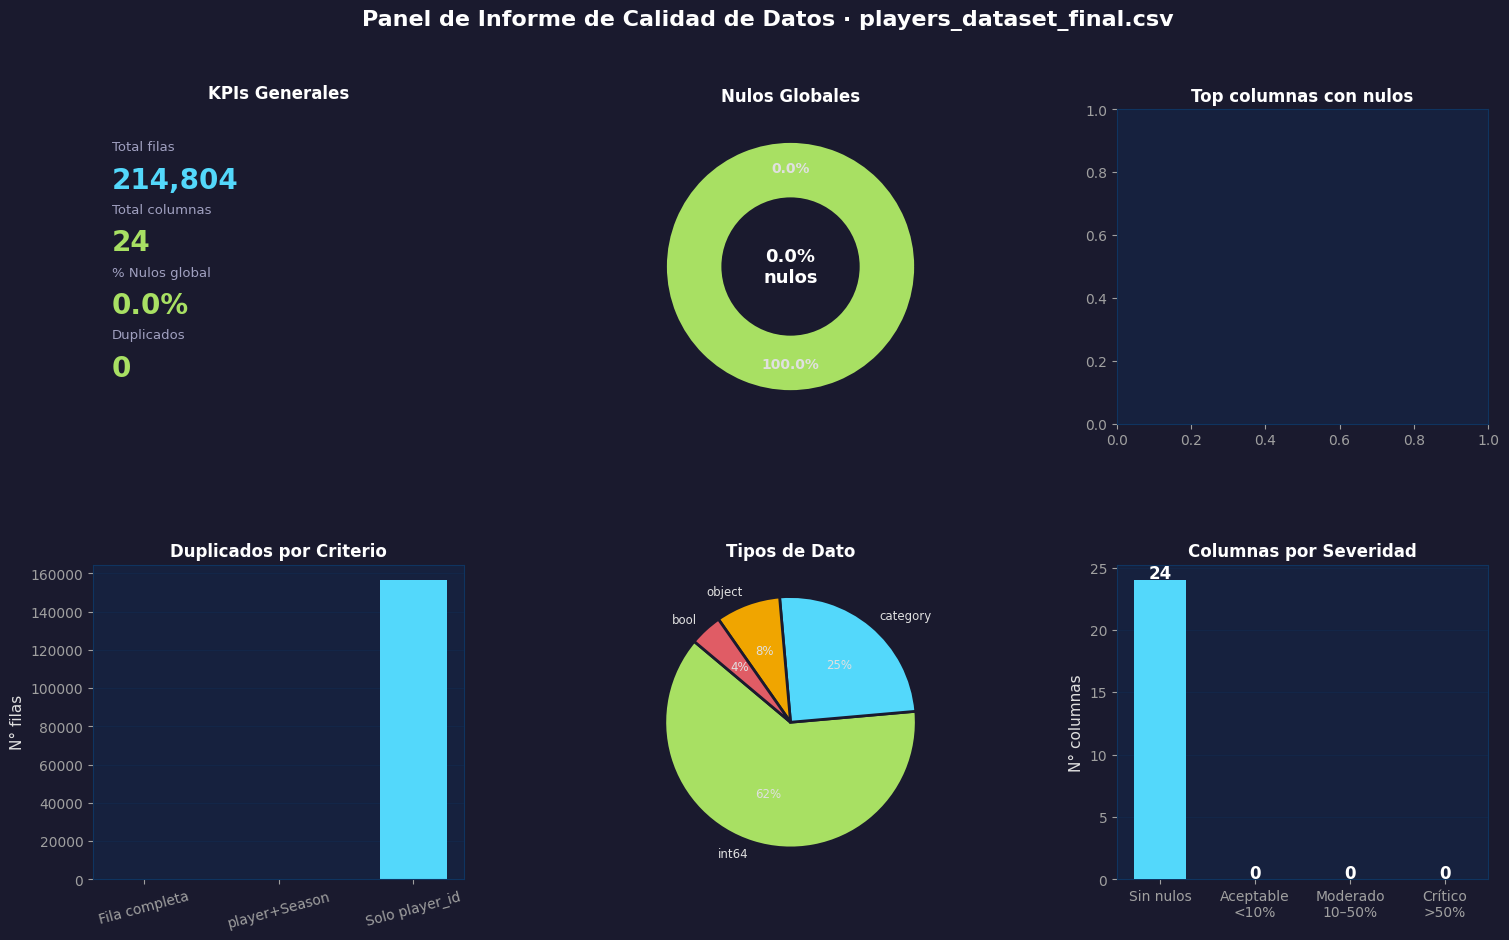

In [ ]:
# ── Métricas generales ──────────────────────────────────
total_filas  = len(df)
total_cols   = len(df.columns)
total_celdas = total_filas * total_cols
total_nulos  = df.isnull().sum().sum()
pct_nulos    = round(total_nulos / total_celdas * 100, 2)
dup_total    = df.duplicated().sum()

# ── Reporte nulos por columna ───────────────────────────
reporte_nulos = pd.DataFrame({
    'columna': df.columns,
    'nulos': df.isnull().sum().values,
    'porcentaje_nulos': (df.isnull().sum() / total_filas * 100).round(2).values
}).sort_values('porcentaje_nulos', ascending=False).reset_index(drop=True)

sin_nulos  = (reporte_nulos['porcentaje_nulos'] == 0).sum()
aceptables = ((reporte_nulos['porcentaje_nulos'] > 0)  & (reporte_nulos['porcentaje_nulos'] <= 10)).sum()
moderadas  = ((reporte_nulos['porcentaje_nulos'] > 10) & (reporte_nulos['porcentaje_nulos'] <= 50)).sum()
criticas   = (reporte_nulos['porcentaje_nulos'] > 50).sum()

# ── Duplicados por criterio ─────────────────────────────
dup_completo   = df.duplicated().sum()
dup_player_sea = df.duplicated(subset=['player_id', 'Season']).sum()
dup_player     = df.duplicated(subset=['player_id']).sum()

resumen_dup = pd.DataFrame({
    'Criterio':   ['Fila completa', 'player+Season', 'Solo player_id'],
    'Duplicados': [dup_completo, dup_player_sea, dup_player]
})

# ── Tipos de dato ───────────────────────────────────────
tipo_counts = (
    df.dtypes.astype(str)
      .value_counts()
      .reset_index()
      .rename(columns={'index': 'tipo', 'count': 'cantidad', 'dtype': 'tipo'})
)
tipo_counts.columns = ['tipo', 'cantidad']

# Resumen del proceso de limpieza

print(f"Filas finales del dataset limpio: {len(df):,}")
print(f"Columnas: {len(df.columns)}")#Resumen
fig = plt.figure(figsize=(18, 10), facecolor=FONDO)
fig.suptitle(
    'Panel de Informe de Calidad de Datos · players_dataset_final.csv',
    fontsize=16, fontweight='bold', color='white', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax_kpi = fig.add_subplot(gs[0, 0])
ax_kpi.set_facecolor(PANEL)
ax_kpi.axis('off')

kpis = [
    ('Total filas',        f'{total_filas:,}',    AZUL_C,  0.82),
    ('Total columnas',     f'{total_cols:,}',      VERDE,   0.62),
    ('% Nulos global',     f'{pct_nulos}%',        ROJO if pct_nulos > 20 else NARANJA if pct_nulos > 5 else VERDE, 0.42),
    ('Duplicados',         f'{dup_total:,}',       ROJO if dup_total > 0 else VERDE,   0.22),
]
for label, val, color, y in kpis:
    ax_kpi.text(0.05, y + 0.05, label, transform=ax_kpi.transAxes,
                fontsize=9.5, color='#a0a0c0')
    ax_kpi.text(0.05, y - 0.07, val, transform=ax_kpi.transAxes,
                fontsize=20, fontweight='bold', color=color)
ax_kpi.set_title('KPIs Generales', fontsize=12, fontweight='bold', pad=8)

#  Donut nulos (fila 0, columna 1)
ax_d = fig.add_subplot(gs[0, 1])
ax_d.set_facecolor(FONDO)
wedges, _, autotexts = ax_d.pie(
    [total_nulos, total_celdas - total_nulos],
    autopct='%1.1f%%', colors=[ROJO, VERDE], startangle=90,
    wedgeprops={'edgecolor': FONDO, 'linewidth': 3}, pctdistance=0.78
)
circle = plt.Circle((0, 0), 0.55, fc=FONDO)
ax_d.add_artist(circle)
ax_d.text(0, 0, f'{pct_nulos}%\nnulos', ha='center', va='center',
          fontsize=13, fontweight='bold', color='white')
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
ax_d.set_title('Nulos Globales', fontsize=12, fontweight='bold')

#  Barras nulos por columna (fila 0, columna 2)
ax_b = fig.add_subplot(gs[0, 2])
ax_b.set_facecolor(PANEL)
top_nulos = reporte_nulos[reporte_nulos['porcentaje_nulos'] > 0].head(10)
if not top_nulos.empty:
    bar_colors = [ROJO if v > 50 else NARANJA if v > 10 else VERDE
                  for v in top_nulos['porcentaje_nulos']]
    ax_b.barh(top_nulos['columna'], top_nulos['porcentaje_nulos'],
              color=bar_colors, height=0.6, edgecolor='none')
    ax_b.axvline(50, color=ROJO,    linestyle='--', lw=1, alpha=0.7)
    ax_b.axvline(10, color=NARANJA, linestyle='--', lw=1, alpha=0.7)
    ax_b.xaxis.grid(True, alpha=0.25)
    ax_b.set_axisbelow(True)
    ax_b.set_xlabel('% Nulos')
ax_b.set_title('Top columnas con nulos', fontsize=12, fontweight='bold')

#  Barras duplicados (fila 1, columna 0)
ax_dup = fig.add_subplot(gs[1, 0])
ax_dup.set_facecolor(PANEL)
ax_dup.bar(resumen_dup['Criterio'], resumen_dup['Duplicados'],
           color=[ROJO, NARANJA, AZUL_C], width=0.5, edgecolor='none')
ax_dup.yaxis.grid(True, alpha=0.3)
ax_dup.set_axisbelow(True)
ax_dup.set_title('Duplicados por Criterio', fontsize=12, fontweight='bold')
ax_dup.set_ylabel('N° filas')
ax_dup.tick_params(axis='x', rotation=15)

# Tipos de dato (fila 1, columna 1)
ax_t = fig.add_subplot(gs[1, 1])
ax_t.set_facecolor(FONDO)
pal2 = [VERDE, AZUL_C, NARANJA, ROJO, AZUL_O, GRIS]
ax_t.pie(
    tipo_counts['cantidad'],
    labels=tipo_counts['tipo'],
    autopct='%1.0f%%',
    colors=pal2[:len(tipo_counts)],
    startangle=140,
    wedgeprops={'edgecolor': FONDO, 'linewidth': 2},
    textprops={'fontsize': 8.5, 'color': '#e0e0e0'}
)
ax_t.set_title('Tipos de Dato', fontsize=12, fontweight='bold')

#Severidad de columnas (fila 1, columna 2)
ax_s = fig.add_subplot(gs[1, 2])
ax_s.set_facecolor(PANEL)
cats2   = ['Sin nulos', 'Aceptable\n<10%', 'Moderado\n10–50%', 'Crítico\n>50%']
counts2 = [sin_nulos, aceptables, moderadas, criticas]
cols3   = [AZUL_C, VERDE, NARANJA, ROJO]
bars3   = ax_s.bar(cats2, counts2, color=cols3, width=0.55, edgecolor='none', zorder=3)
for bar, v in zip(bars3, counts2):
    ax_s.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
              str(v), ha='center', fontsize=12, fontweight='bold', color='white')
ax_s.yaxis.grid(True, alpha=0.3, zorder=0)
ax_s.set_axisbelow(True)
ax_s.set_title('Columnas por Severidad', fontsize=12, fontweight='bold')
ax_s.set_ylabel('N° columnas')

plt.savefig('dashboard_calidad_datos.png', dpi=150, bbox_inches='tight',
            facecolor=FONDO, edgecolor='none')
plt.show()

# Implementar Imputaciones por Tipo
Justificar cada decisión con métricas de calidad.


# Metricas

In [ ]:

# porcentaje de faltantes por temporada
missing_por_season = df.groupby("Season").apply(
    lambda x: x.isnull().mean() * 100
)

pd.set_option('display.max_columns', None)
display(missing_por_season)

,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,posicion_principal,preferred_foot_valido
Season,,,,,,,,,,,,,,,,,,,,,,,,
2015,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2018,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2019,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2020,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2021,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2022,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2023,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
# Métrica de completitud general
# Columnas que ocupan imputacion
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

print(pd.DataFrame({
    "faltantes": missing,
    "porcentaje": missing_percent
}).sort_values("porcentaje", ascending=False))

                       faltantes  porcentaje
Season                         0        0.00
player_id                      0        0.00
short_name                     0        0.00
age                            0        0.00
nationality                    0        0.00
club_name                      0        0.00
league_name                    0        0.00
player_positions               0        0.00
club_position                  0        0.00
preferred_foot                 0        0.00
height_cm                      0        0.00
weight_kg                      0        0.00
overall                        0        0.00
potential                      0        0.00
value_eur                      0        0.00
wage_eur                       0        0.00
pace                           0        0.00
shooting                       0        0.00
passing                        0        0.00
dribbling                      0        0.00
defending                      0        0.00
physic    

In [ ]:
# Métrica de cobertura histórica
# Verificar que el histórico tiene suficientes datos para imputar.
df_historico = df[df["Season"] <= 2023]

df_historico.isnull().mean() * 100

,0
Season,0.00
player_id,0.00
short_name,0.00
age,0.00
nationality,0.00
club_name,0.00
league_name,0.00
player_positions,0.00
club_position,0.00
preferred_foot,0.00


In [ ]:
# Métrica de distribución estadística
pd.set_option('display.float_format', '{:.2f}'.format)
df_historico["height_cm"].describe()

,height_cm
count,198959.00
mean,181.12
std,6.74
min,149.00
25%,176.00
50%,181.00
75%,186.00
max,210.00


In [ ]:
# Métrica de correlación pequeña porque son pocos datos, mejorar interfaz
df_historico[["overall","value_eur","wage_eur","potential"]].corr()

,overall,value_eur,wage_eur,potential
overall,1.00,0.54,0.59,0.69
value_eur,0.54,1.00,0.78,0.52
wage_eur,0.59,0.78,1.00,0.50
potential,0.69,0.52,0.50,1.00


# Imputación

In [ ]:
import pandas as pd
import os
ruta_base = "/content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar"

salida = os.path.join(ruta_base, "players_dataset_final_imputado.csv")


print("Filas:", len(df))

# historial antes de 2024
df_hist = df[df["Season"] < 2024]

# agrupar jugadores
grupos = df_hist.groupby("player_id")

print("Imputando variables...")

contador_imputados = 0
contador_sin_historial = 0

# recorrer jugadores del 2024
for idx, fila in df[df["Season"] == 2024].iterrows():

    player = fila["player_id"]

    # si no existe historial → NO imputar
    if player not in grupos.groups:
        contador_sin_historial += 1
        continue

    historial = grupos.get_group(player)

    # usar últimos 9 años
    historial = historial.sort_values("Season").tail(9)

    # POTENTIAL

    valores = historial["potential"].dropna()

    if len(valores) > 0:

        mediana = int(round(valores.median()))

        mediana = max(min(mediana, 99), 10)

        df.loc[idx, "potential"] = mediana

        contador_imputados += 1

    # VALUE_EUR


    valores = historial["value_eur"].dropna()

    if len(valores) > 0:

        mediana = valores.median()

        df.loc[idx, "value_eur"] = mediana

        contador_imputados += 1

    # WAGE_EUR

    valores = historial["wage_eur"].dropna()

    if len(valores) > 0:

        mediana = valores.median()

        df.loc[idx, "wage_eur"] = mediana

        contador_imputados += 1


print("Guardando dataset...")
df.to_csv(salida, index=False)

print("----------------------------")
print("Valores imputados:", contador_imputados)
print("Jugadores sin historial:", contador_sin_historial)
print("Archivo generado:", salida)

Filas: 214804
Imputando variables...
Guardando dataset...
----------------------------
Valores imputados: 43446
Jugadores sin historial: 1363
Archivo generado: /content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar/players_dataset_final_imputado.csv


In [ ]:

archivo = "/content/drive/MyDrive/Proyecto/datasets/datasets_reduccion/datasets_normalizar/players_dataset_final_imputado.csv"

df = pd.read_csv(archivo, low_memory=False)
pd.set_option('display.max_columns', None)
player_id = 158023
df_jugador = df[df["player_id"] == player_id].copy()
df_jugador = df_jugador.sort_values("Season")
df_jugador = df_jugador.groupby("Season").first().reset_index()

print(f"Historial del jugador ID {player_id} (una fila por año):\n")
display(df_jugador)

Historial del jugador ID 158023 (una fila por año):



,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,posicion_principal,preferred_foot_valido
0,2015,158023,L. Messi,27,Argentina,FC Barcelona,Spain Primera Division,CF,CF,Left,169,67,93,95,100500000,550000,93,89,86,96,27,63,CF,True
1,2016,158023,L. Messi,28,Argentina,FC Barcelona,Spain Primera Division,"RW, CF",RW,Left,170,72,94,95,111000000,550000,92,88,86,95,24,62,RW,True
2,2017,158023,L. Messi,29,Argentina,FC Barcelona,Spain Primera Division,RW,RW,Left,170,72,93,93,89000000,575000,89,90,86,96,26,61,RW,True
3,2018,158023,L. Messi,30,Argentina,FC Barcelona,Spain Primera Division,RW,RW,Left,170,72,93,93,105000000,575000,89,90,86,96,26,61,RW,True
4,2019,158023,L. Messi,31,Argentina,FC Barcelona,Spain Primera Division,"CF, RW, ST",RW,Left,170,72,94,94,110500000,575000,88,91,88,96,32,61,CF,True
5,2020,158023,L. Messi,32,Argentina,FC Barcelona,Spain Primera Division,"RW, CF, ST",RW,Left,170,72,94,94,95500000,560000,87,92,92,96,39,66,RW,True
6,2021,158023,L. Messi,33,Argentina,FC Barcelona,Spain Primera Division,"RW, ST, CF",CAM,Left,170,72,93,93,103500000,560000,85,92,91,95,38,65,RW,True
7,2022,158023,L. Messi,34,Argentina,Paris Saint-Germain,French Ligue 1,"RW, ST, CF",RW,Left,170,72,93,93,78000000,320000,85,92,91,95,34,65,RW,True
8,2023,158023,L. Messi,35,Argentina,Paris Saint Germain,Ligue 1,RW,RS,Left,169,67,91,91,54000000,195000,81,89,90,94,34,64,RW,True
9,2024,158023,L. Messi,36,Argentina,Inter Miami CF,Ligue 1,CF,CF,Left,169,67,90,93,100500000,560000,80,87,90,96,33,64,CF,True


# 6 Features derivados complejos


In [ ]:
# Feature derivado — GrupoAltura
# Clasifica jugadores según su altura en 3 niveles
# Rangos basados en distribución real de jugadores de fútbol

import pandas as pd


# Función para clasificar altura
def clasificar_altura(altura):
    if pd.isna(altura):
        return None
    elif altura < 175:
        return "Bajo"
    elif altura <= 185:
        return "Medio"
    else:
        return "Alto"

# Crear la columna derivada
df["GrupoAltura"] = df["height_cm"].apply(clasificar_altura)

# Mostrar distribución
print("Distribución de GrupoAltura:")
print(df["GrupoAltura"].value_counts())

print(f"\n% por grupo:")
print((df["GrupoAltura"].value_counts(normalize=True) * 100).round(2))

# Mostrar dataframe completo
display(df.head(10))

Distribución de GrupoAltura:
GrupoAltura
Medio    124266
Alto      56283
Bajo      34255
Name: count, dtype: int64

% por grupo:
GrupoAltura
Medio   57.85
Alto    26.20
Bajo    15.95
Name: proportion, dtype: float64


,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,posicion_principal,preferred_foot_valido,GrupoAltura
0,2015,158023,L. Messi,27,Argentina,FC Barcelona,Spain Primera Division,CF,CF,Left,169,67,93,95,100500000,550000,93,89,86,96,27,63,CF,True,Bajo
1,2015,20801,Cristiano Ronaldo,29,Portugal,Real Madrid CF,Spain Primera Division,"LW, LM",LW,Right,185,80,92,92,79000000,375000,93,93,81,91,32,79,LW,True,Medio
2,2015,9014,A. Robben,30,Netherlands,FC Bayern München,German 1. Bundesliga,"RM, LM, RW",SUB,Left,180,80,90,90,54500000,275000,93,86,83,92,32,64,RM,True,Medio
3,2015,41236,Z. Ibrahimović,32,Sweden,Paris Saint-Germain,French Ligue 1,ST,ST,Right,195,95,90,90,52500000,275000,76,91,81,86,34,86,ST,True,Alto
4,2015,167495,M. Neuer,28,Germany,FC Bayern München,German 1. Bundesliga,GK,GK,Right,193,92,90,90,63500000,300000,68,54,57,62,55,65,GK,True,Alto
5,2015,41,Iniesta,30,Spain,FC Barcelona,Spain Primera Division,"CM, LW",LCM,Right,170,65,89,89,36000000,250000,75,72,89,91,59,63,CM,True,Bajo
6,2015,176580,L. Suárez,27,Uruguay,FC Barcelona,Spain Primera Division,"ST, CF",RES,Right,181,81,89,91,49500000,300000,83,87,79,88,42,79,ST,True,Medio
7,2015,7826,R. van Persie,30,Netherlands,Manchester United,English Premier League,ST,RS,Left,187,71,88,88,40500000,230000,74,90,82,83,33,68,ST,True,Alto
8,2015,121944,B. Schweinsteiger,29,Germany,FC Bayern München,German 1. Bundesliga,"CM, CDM",SUB,Right,183,79,88,88,39000000,200000,61,81,85,82,78,80,CM,True,Medio
9,2015,156616,F. Ribéry,31,France,FC Bayern München,German 1. Bundesliga,LM,SUB,Right,170,72,88,88,33000000,200000,89,78,85,92,29,62,LM,True,Bajo


In [ ]:
# Feature derivado — GrupoValor
# Clasifica jugadores según su valor de mercado en 3 niveles
# Umbrales basados en Q1 y Q3 del dataset
df_final = df
def clasificar_valor(valor):
    if pd.isna(valor):
        return None
    elif valor < 300_000:
        return "Bajo"
    elif valor <= 1_600_000:
        return "Medio"
    else:
        return "Alto"

df_final["GrupoValor"] = df_final["value_eur"].apply(clasificar_valor)

print("Distribución de GrupoValor:")
print(df_final["GrupoValor"].value_counts())
print(f"\n% por grupo:")
print((df_final["GrupoValor"].value_counts(normalize=True) * 100).round(2))

display(df_final.head(10))

Distribución de GrupoValor:
GrupoValor
Medio    112699
Bajo      53461
Alto      48644
Name: count, dtype: int64

% por grupo:
GrupoValor
Medio   52.47
Bajo    24.89
Alto    22.65
Name: proportion, dtype: float64


,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,posicion_principal,preferred_foot_valido,GrupoAltura,GrupoValor
0,2015,158023,L. Messi,27,Argentina,FC Barcelona,Spain Primera Division,CF,CF,Left,169,67,93,95,100500000,550000,93,89,86,96,27,63,CF,True,Bajo,Alto
1,2015,20801,Cristiano Ronaldo,29,Portugal,Real Madrid CF,Spain Primera Division,"LW, LM",LW,Right,185,80,92,92,79000000,375000,93,93,81,91,32,79,LW,True,Medio,Alto
2,2015,9014,A. Robben,30,Netherlands,FC Bayern München,German 1. Bundesliga,"RM, LM, RW",SUB,Left,180,80,90,90,54500000,275000,93,86,83,92,32,64,RM,True,Medio,Alto
3,2015,41236,Z. Ibrahimović,32,Sweden,Paris Saint-Germain,French Ligue 1,ST,ST,Right,195,95,90,90,52500000,275000,76,91,81,86,34,86,ST,True,Alto,Alto
4,2015,167495,M. Neuer,28,Germany,FC Bayern München,German 1. Bundesliga,GK,GK,Right,193,92,90,90,63500000,300000,68,54,57,62,55,65,GK,True,Alto,Alto
5,2015,41,Iniesta,30,Spain,FC Barcelona,Spain Primera Division,"CM, LW",LCM,Right,170,65,89,89,36000000,250000,75,72,89,91,59,63,CM,True,Bajo,Alto
6,2015,176580,L. Suárez,27,Uruguay,FC Barcelona,Spain Primera Division,"ST, CF",RES,Right,181,81,89,91,49500000,300000,83,87,79,88,42,79,ST,True,Medio,Alto
7,2015,7826,R. van Persie,30,Netherlands,Manchester United,English Premier League,ST,RS,Left,187,71,88,88,40500000,230000,74,90,82,83,33,68,ST,True,Alto,Alto
8,2015,121944,B. Schweinsteiger,29,Germany,FC Bayern München,German 1. Bundesliga,"CM, CDM",SUB,Right,183,79,88,88,39000000,200000,61,81,85,82,78,80,CM,True,Medio,Alto
9,2015,156616,F. Ribéry,31,France,FC Bayern München,German 1. Bundesliga,LM,SUB,Right,170,72,88,88,33000000,200000,89,78,85,92,29,62,LM,True,Bajo,Alto


In [ ]:
# Feature derivado — GrupoEdad
# Clasifica jugadores según su edad en 3 etapas de carrera
# Rangos basados en el ejemplo del proyecto: young < 21, prime 21–28, veteran > 28

def clasificar_edad(edad):
    if pd.isna(edad):
        return None
    elif edad < 21:
        return "Young"
    elif edad <= 28:
        return "Prime"
    else:
        return "Veteran"

df_final["GrupoEdad"] = df_final["age"].apply(clasificar_edad)

print("Distribución de GrupoEdad:")
print(df_final["GrupoEdad"].value_counts())
print(f"\n% por grupo:")
print((df_final["GrupoEdad"].value_counts(normalize=True) * 100).round(2))
display(df_final.head(10))

Distribución de GrupoEdad:
GrupoEdad
Prime      118259
Veteran     55022
Young       41523
Name: count, dtype: int64

% por grupo:
GrupoEdad
Prime     55.05
Veteran   25.61
Young     19.33
Name: proportion, dtype: float64


,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,posicion_principal,preferred_foot_valido,GrupoAltura,GrupoValor,GrupoEdad
0,2015,158023,L. Messi,27,Argentina,FC Barcelona,Spain Primera Division,CF,CF,Left,169,67,93,95,100500000,550000,93,89,86,96,27,63,CF,True,Bajo,Alto,Prime
1,2015,20801,Cristiano Ronaldo,29,Portugal,Real Madrid CF,Spain Primera Division,"LW, LM",LW,Right,185,80,92,92,79000000,375000,93,93,81,91,32,79,LW,True,Medio,Alto,Veteran
2,2015,9014,A. Robben,30,Netherlands,FC Bayern München,German 1. Bundesliga,"RM, LM, RW",SUB,Left,180,80,90,90,54500000,275000,93,86,83,92,32,64,RM,True,Medio,Alto,Veteran
3,2015,41236,Z. Ibrahimović,32,Sweden,Paris Saint-Germain,French Ligue 1,ST,ST,Right,195,95,90,90,52500000,275000,76,91,81,86,34,86,ST,True,Alto,Alto,Veteran
4,2015,167495,M. Neuer,28,Germany,FC Bayern München,German 1. Bundesliga,GK,GK,Right,193,92,90,90,63500000,300000,68,54,57,62,55,65,GK,True,Alto,Alto,Prime
5,2015,41,Iniesta,30,Spain,FC Barcelona,Spain Primera Division,"CM, LW",LCM,Right,170,65,89,89,36000000,250000,75,72,89,91,59,63,CM,True,Bajo,Alto,Veteran
6,2015,176580,L. Suárez,27,Uruguay,FC Barcelona,Spain Primera Division,"ST, CF",RES,Right,181,81,89,91,49500000,300000,83,87,79,88,42,79,ST,True,Medio,Alto,Prime
7,2015,7826,R. van Persie,30,Netherlands,Manchester United,English Premier League,ST,RS,Left,187,71,88,88,40500000,230000,74,90,82,83,33,68,ST,True,Alto,Alto,Veteran
8,2015,121944,B. Schweinsteiger,29,Germany,FC Bayern München,German 1. Bundesliga,"CM, CDM",SUB,Right,183,79,88,88,39000000,200000,61,81,85,82,78,80,CM,True,Medio,Alto,Veteran
9,2015,156616,F. Ribéry,31,France,FC Bayern München,German 1. Bundesliga,LM,SUB,Right,170,72,88,88,33000000,200000,89,78,85,92,29,62,LM,True,Bajo,Alto,Veteran


In [ ]:
# Feature derivado — BrechaPotencial
# Calcula la diferencia entre el potencial máximo y el overall actual del jugador
# Valores altos indican jugadores con mayor margen de mejora (talentos sin explotar)

df_final["BrechaPotencial"] = df_final["potential"] - df_final["overall"]

print("Estadísticas de BrechaPotencial:")
print(df_final["BrechaPotencial"].describe().round(2))
display(df_final.head(10))

Estadísticas de BrechaPotencial:
count   214804.00
mean         5.13
std          5.29
min        -15.00
25%          0.00
50%          4.00
75%          9.00
max         28.00
Name: BrechaPotencial, dtype: float64


,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,posicion_principal,preferred_foot_valido,GrupoAltura,GrupoValor,GrupoEdad,BrechaPotencial
0,2015,158023,L. Messi,27,Argentina,FC Barcelona,Spain Primera Division,CF,CF,Left,169,67,93,95,100500000,550000,93,89,86,96,27,63,CF,True,Bajo,Alto,Prime,2
1,2015,20801,Cristiano Ronaldo,29,Portugal,Real Madrid CF,Spain Primera Division,"LW, LM",LW,Right,185,80,92,92,79000000,375000,93,93,81,91,32,79,LW,True,Medio,Alto,Veteran,0
2,2015,9014,A. Robben,30,Netherlands,FC Bayern München,German 1. Bundesliga,"RM, LM, RW",SUB,Left,180,80,90,90,54500000,275000,93,86,83,92,32,64,RM,True,Medio,Alto,Veteran,0
3,2015,41236,Z. Ibrahimović,32,Sweden,Paris Saint-Germain,French Ligue 1,ST,ST,Right,195,95,90,90,52500000,275000,76,91,81,86,34,86,ST,True,Alto,Alto,Veteran,0
4,2015,167495,M. Neuer,28,Germany,FC Bayern München,German 1. Bundesliga,GK,GK,Right,193,92,90,90,63500000,300000,68,54,57,62,55,65,GK,True,Alto,Alto,Prime,0
5,2015,41,Iniesta,30,Spain,FC Barcelona,Spain Primera Division,"CM, LW",LCM,Right,170,65,89,89,36000000,250000,75,72,89,91,59,63,CM,True,Bajo,Alto,Veteran,0
6,2015,176580,L. Suárez,27,Uruguay,FC Barcelona,Spain Primera Division,"ST, CF",RES,Right,181,81,89,91,49500000,300000,83,87,79,88,42,79,ST,True,Medio,Alto,Prime,2
7,2015,7826,R. van Persie,30,Netherlands,Manchester United,English Premier League,ST,RS,Left,187,71,88,88,40500000,230000,74,90,82,83,33,68,ST,True,Alto,Alto,Veteran,0
8,2015,121944,B. Schweinsteiger,29,Germany,FC Bayern München,German 1. Bundesliga,"CM, CDM",SUB,Right,183,79,88,88,39000000,200000,61,81,85,82,78,80,CM,True,Medio,Alto,Veteran,0
9,2015,156616,F. Ribéry,31,France,FC Bayern München,German 1. Bundesliga,LM,SUB,Right,170,72,88,88,33000000,200000,89,78,85,92,29,62,LM,True,Bajo,Alto,Veteran,0


In [ ]:
# Feature derivado — PosicionPrincipal
# Extrae la primera posición listada en player_positions como posición predominante
# Se asume que el orden en FIFA refleja la posición principal del jugador
# Resuelve el problema de alta cardinalidad de player_positions 2905 valores únicos

df_final["PosicionPrincipal"] = df_final["player_positions"].str.split(",").str[0].str.strip()

print("Distribución de PosicionPrincipal:")
print(df_final["PosicionPrincipal"].value_counts().head(10))
print(f"\n% por posición:")
print((df_final["PosicionPrincipal"].value_counts(normalize=True) * 100).round(2).head(10))
display(df_final.head(10))

Distribución de PosicionPrincipal:
PosicionPrincipal
CB     36741
ST     31367
CM     25194
GK     24043
CDM    17128
RB     15421
LB     15245
CAM    13000
RM     11919
LM     11918
Name: count, dtype: int64

% por posición:
PosicionPrincipal
CB    17.10
ST    14.60
CM    11.73
GK    11.19
CDM    7.97
RB     7.18
LB     7.10
CAM    6.05
RM     5.55
LM     5.55
Name: proportion, dtype: float64


,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,posicion_principal,preferred_foot_valido,GrupoAltura,GrupoValor,GrupoEdad,BrechaPotencial,PosicionPrincipal
0,2015,158023,L. Messi,27,Argentina,FC Barcelona,Spain Primera Division,CF,CF,Left,169,67,93,95,100500000,550000,93,89,86,96,27,63,CF,True,Bajo,Alto,Prime,2,CF
1,2015,20801,Cristiano Ronaldo,29,Portugal,Real Madrid CF,Spain Primera Division,"LW, LM",LW,Right,185,80,92,92,79000000,375000,93,93,81,91,32,79,LW,True,Medio,Alto,Veteran,0,LW
2,2015,9014,A. Robben,30,Netherlands,FC Bayern München,German 1. Bundesliga,"RM, LM, RW",SUB,Left,180,80,90,90,54500000,275000,93,86,83,92,32,64,RM,True,Medio,Alto,Veteran,0,RM
3,2015,41236,Z. Ibrahimović,32,Sweden,Paris Saint-Germain,French Ligue 1,ST,ST,Right,195,95,90,90,52500000,275000,76,91,81,86,34,86,ST,True,Alto,Alto,Veteran,0,ST
4,2015,167495,M. Neuer,28,Germany,FC Bayern München,German 1. Bundesliga,GK,GK,Right,193,92,90,90,63500000,300000,68,54,57,62,55,65,GK,True,Alto,Alto,Prime,0,GK
5,2015,41,Iniesta,30,Spain,FC Barcelona,Spain Primera Division,"CM, LW",LCM,Right,170,65,89,89,36000000,250000,75,72,89,91,59,63,CM,True,Bajo,Alto,Veteran,0,CM
6,2015,176580,L. Suárez,27,Uruguay,FC Barcelona,Spain Primera Division,"ST, CF",RES,Right,181,81,89,91,49500000,300000,83,87,79,88,42,79,ST,True,Medio,Alto,Prime,2,ST
7,2015,7826,R. van Persie,30,Netherlands,Manchester United,English Premier League,ST,RS,Left,187,71,88,88,40500000,230000,74,90,82,83,33,68,ST,True,Alto,Alto,Veteran,0,ST
8,2015,121944,B. Schweinsteiger,29,Germany,FC Bayern München,German 1. Bundesliga,"CM, CDM",SUB,Right,183,79,88,88,39000000,200000,61,81,85,82,78,80,CM,True,Medio,Alto,Veteran,0,CM
9,2015,156616,F. Ribéry,31,France,FC Bayern München,German 1. Bundesliga,LM,SUB,Right,170,72,88,88,33000000,200000,89,78,85,92,29,62,LM,True,Bajo,Alto,Veteran,0,LM


In [ ]:
# Feature derivado — EficienciaFinanciera
# Indica cuántas veces el valor de mercado del jugador supera su salario anual
# Ejemplo: un jugador que vale €10M y gana €100K tiene una eficiencia de 100
# Jugadores con eficiencia alta son más rentables para el club

df_final["EficienciaFinanciera"] = (df_final["value_eur"] / df_final["wage_eur"]).round(2)
df_final["EficienciaFinanciera"] = df_final["EficienciaFinanciera"].replace([np.inf, -np.inf], np.nan)

print("Estadísticas de EficienciaFinanciera:")
print(df_final["EficienciaFinanciera"].describe().round(2))
display(df_final.head(10))

Estadísticas de EficienciaFinanciera:
count   214804.00
mean       339.55
std        667.83
min          0.05
25%         95.00
50%        190.00
75%        355.00
max      35000.00
Name: EficienciaFinanciera, dtype: float64


,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,posicion_principal,preferred_foot_valido,GrupoAltura,GrupoValor,GrupoEdad,BrechaPotencial,PosicionPrincipal,EficienciaFinanciera
0,2015,158023,L. Messi,27,Argentina,FC Barcelona,Spain Primera Division,CF,CF,Left,169,67,93,95,100500000,550000,93,89,86,96,27,63,CF,True,Bajo,Alto,Prime,2,CF,182.73
1,2015,20801,Cristiano Ronaldo,29,Portugal,Real Madrid CF,Spain Primera Division,"LW, LM",LW,Right,185,80,92,92,79000000,375000,93,93,81,91,32,79,LW,True,Medio,Alto,Veteran,0,LW,210.67
2,2015,9014,A. Robben,30,Netherlands,FC Bayern München,German 1. Bundesliga,"RM, LM, RW",SUB,Left,180,80,90,90,54500000,275000,93,86,83,92,32,64,RM,True,Medio,Alto,Veteran,0,RM,198.18
3,2015,41236,Z. Ibrahimović,32,Sweden,Paris Saint-Germain,French Ligue 1,ST,ST,Right,195,95,90,90,52500000,275000,76,91,81,86,34,86,ST,True,Alto,Alto,Veteran,0,ST,190.91
4,2015,167495,M. Neuer,28,Germany,FC Bayern München,German 1. Bundesliga,GK,GK,Right,193,92,90,90,63500000,300000,68,54,57,62,55,65,GK,True,Alto,Alto,Prime,0,GK,211.67
5,2015,41,Iniesta,30,Spain,FC Barcelona,Spain Primera Division,"CM, LW",LCM,Right,170,65,89,89,36000000,250000,75,72,89,91,59,63,CM,True,Bajo,Alto,Veteran,0,CM,144.00
6,2015,176580,L. Suárez,27,Uruguay,FC Barcelona,Spain Primera Division,"ST, CF",RES,Right,181,81,89,91,49500000,300000,83,87,79,88,42,79,ST,True,Medio,Alto,Prime,2,ST,165.00
7,2015,7826,R. van Persie,30,Netherlands,Manchester United,English Premier League,ST,RS,Left,187,71,88,88,40500000,230000,74,90,82,83,33,68,ST,True,Alto,Alto,Veteran,0,ST,176.09
8,2015,121944,B. Schweinsteiger,29,Germany,FC Bayern München,German 1. Bundesliga,"CM, CDM",SUB,Right,183,79,88,88,39000000,200000,61,81,85,82,78,80,CM,True,Medio,Alto,Veteran,0,CM,195.00
9,2015,156616,F. Ribéry,31,France,FC Bayern München,German 1. Bundesliga,LM,SUB,Right,170,72,88,88,33000000,200000,89,78,85,92,29,62,LM,True,Bajo,Alto,Veteran,0,LM,165.00


# 3 Features de Seguridad
Estas son reglas o indicadores para identificar datos potencialmente
inválidos o poco confiables y para proteger el proceso de análisis de ruido

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import sklearn
import time
import gc

In [ ]:
print(f"Filas: {df_final.shape[0]}")
print(f"Columnas: {df_final.shape[1]}")

Filas: 214804
Columnas: 33


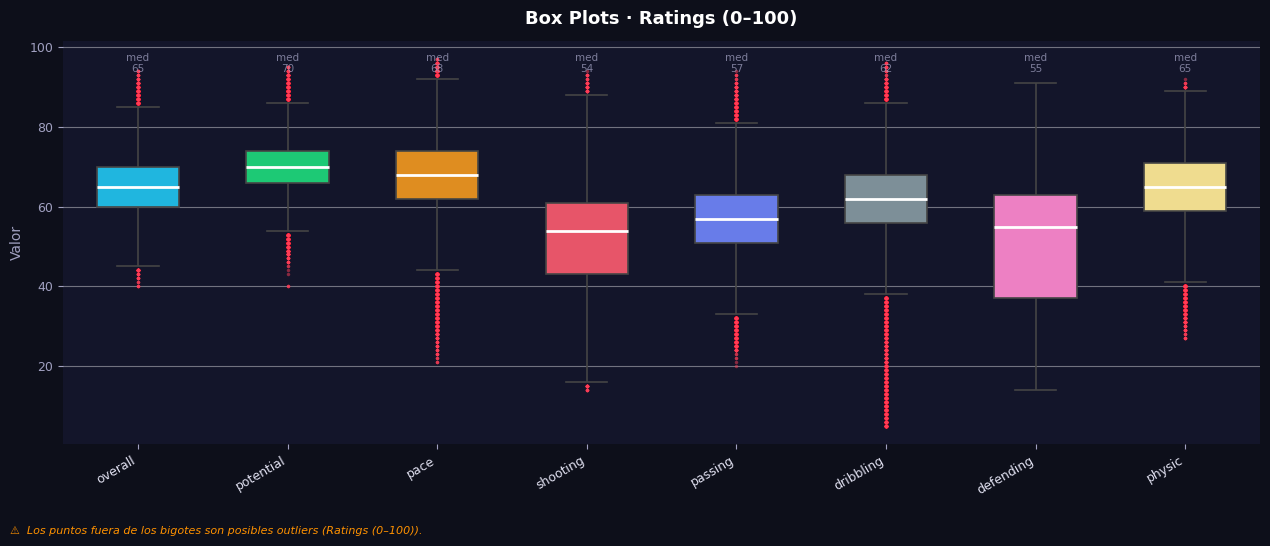

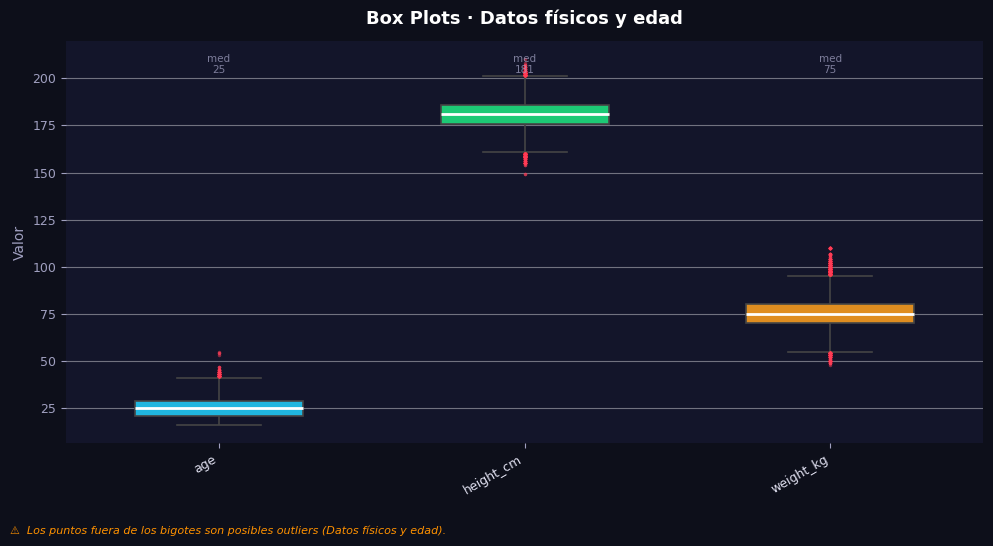

0

In [ ]:
# 8.1 — Box plots de atributos principales — estilo dashboard calidad de datos
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import gc

# ── Paleta idéntica al dashboard de calidad ──────────────────────────────────
FONDO  = '#0d0f1a'
PANEL  = '#13152a'
AZUL_C = '#00c8ff'
VERDE  = '#00e676'
NARANJA= '#ff9100'
ROJO   = '#ff3d57'
AZUL_O = '#536dfe'
GRIS   = '#78909c'
TEXTO  = '#e0e0f0'
TEXTO2 = '#a0a0c0'

PALETA_BOX = [AZUL_C, VERDE, NARANJA, ROJO, AZUL_O, GRIS,
              '#ff6ec7', '#ffe57f', '#69ffdc', '#b388ff']

grupos = {
    "Ratings (0–100)": [
        "overall", "potential",
        "pace", "shooting", "passing",
        "dribbling", "defending", "physic",
    ],
    "Datos físicos y edad": [
        "age", "height_cm", "weight_kg",
    ],
}

for titulo, cols in grupos.items():
    cols = [c for c in cols if c in df_final.columns]
    if not cols:
        continue

    n = len(cols)
    fig, ax = plt.subplots(figsize=(max(10, n * 1.6), 5.5), facecolor=FONDO)
    ax.set_facecolor(PANEL)

    # ── Box plot con paleta del dashboard ────────────────────────────────────
    bp = sns.boxplot(
        data=df_final[cols], ax=ax,
        palette=PALETA_BOX[:n],
        width=0.55,
        linewidth=1.4,
        flierprops=dict(marker='o', markersize=2.5,
                        markerfacecolor=ROJO, markeredgecolor='none', alpha=0.5),
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    # ── Estilo de ejes igual al dashboard ────────────────────────────────────
    ax.set_title(f'Box Plots · {titulo}',
                 fontsize=13, fontweight='bold', color='white', pad=12)
    ax.set_ylabel('Valor', color=TEXTO2, fontsize=10)
    ax.tick_params(colors=TEXTO2, labelsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', color=TEXTO)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.yaxis.grid(True, color='#ffffff18', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.xaxis.grid(False)

    # ── Etiqueta de mediana sobre cada caja ──────────────────────────────────
    medians = df_final[cols].median()
    for i, (col, med) in enumerate(medians.items()):
        ax.text(i, ax.get_ylim()[1] * 0.97,
                f'med\n{med:.0f}',
                ha='center', va='top',
                fontsize=7.5, color=TEXTO2, alpha=0.75)

    # ── Nota al pie ──────────────────────────────────────────────────────────
    fig.text(0.012, 0.02,
             f'⚠  Los puntos fuera de los bigotes son posibles outliers ({titulo}).',
             fontsize=8, color=NARANJA, style='italic')

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(f'boxplot_{titulo[:20].replace(" ","_")}.png',
                dpi=150, bbox_inches='tight', facecolor=FONDO, edgecolor='none')
    plt.show()
    plt.close('all')
    gc.collect()

gc.collect()


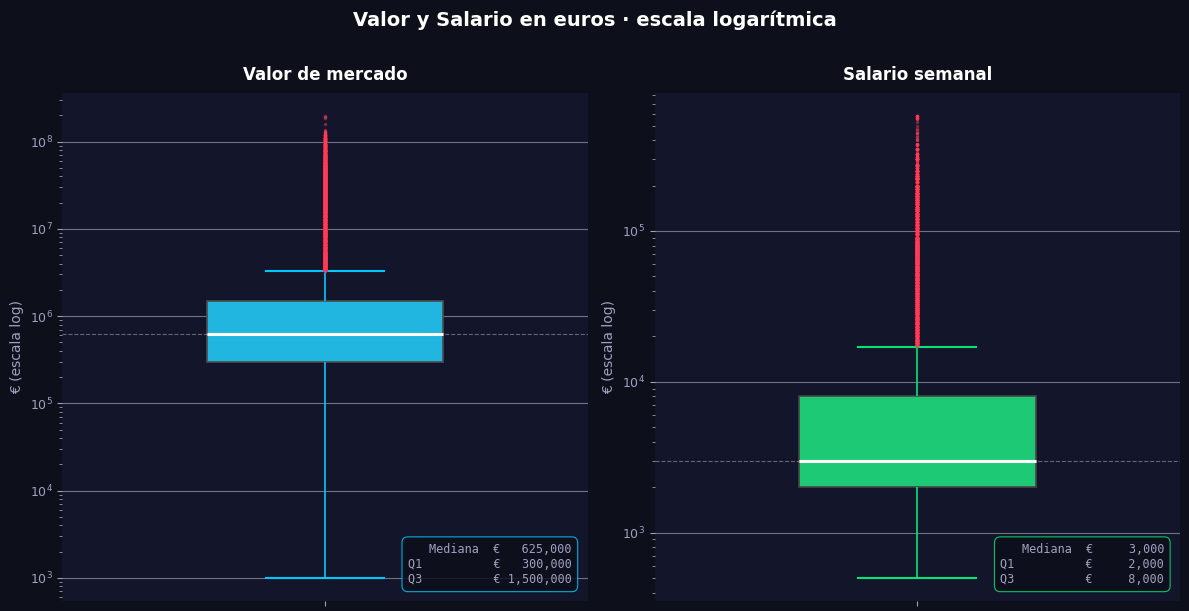

22652

In [ ]:
# 8.1 — Box plots Valor y Salario con escala logarítmica — estilo dashboard
import gc

FONDO  = '#0d0f1a'
PANEL  = '#13152a'
AZUL_C = '#00c8ff'
VERDE  = '#00e676'
NARANJA= '#ff9100'
ROJO   = '#ff3d57'
TEXTO  = '#e0e0f0'
TEXTO2 = '#a0a0c0'

fig, axes = plt.subplots(1, 2, figsize=(12, 6), facecolor=FONDO)
fig.suptitle(
    'Valor y Salario en euros · escala logarítmica',
    fontsize=14, fontweight='bold', color='white', y=1.01
)

colores = [AZUL_C, VERDE]

for ax, col, color in zip(axes, ['value_eur', 'wage_eur'], colores):
    if col not in df_final.columns:
        ax.axis('off')
        continue

    datos = df_final[col].dropna()
    datos = datos[datos > 0]

    ax.set_facecolor(PANEL)

    sns.boxplot(
        y=datos, ax=ax,
        color=color,
        width=0.45,
        linewidth=1.4,
        flierprops=dict(marker='o', markersize=2.5,
                        markerfacecolor=ROJO, markeredgecolor='none', alpha=0.45),
        medianprops=dict(color='white', linewidth=2.2),
        whiskerprops=dict(color=color, linewidth=1.2),
        capprops=dict(color=color, linewidth=1.5),
        boxprops=dict(linewidth=1.2),
    )

    ax.set_yscale('log')

    # ── Estilo ejes ──────────────────────────────────────────────────────────
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.yaxis.grid(True, color='#ffffff15', linewidth=0.8)
    ax.set_axisbelow(True)
    ax.xaxis.grid(False)
    ax.tick_params(colors=TEXTO2, labelsize=9)
    ax.set_ylabel('€ (escala log)', color=TEXTO2, fontsize=10)
    ax.set_xlabel('')

    label = 'Valor de mercado' if col == 'value_eur' else 'Salario semanal'
    ax.set_title(label, fontsize=12, fontweight='bold', color='white', pad=10)

    # ── Estadísticos clave como anotaciones flotantes ───────────────────────
    q1, med, q3 = datos.quantile([0.25, 0.5, 0.75])
    stats_txt = f'Mediana  €{med:>10,.0f}\nQ1          €{q1:>10,.0f}\nQ3          €{q3:>10,.0f}'
    ax.text(
        0.97, 0.03, stats_txt,
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8.5, color=TEXTO2, family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor=FONDO, edgecolor=color, linewidth=0.8, alpha=0.85)
    )

    # ── Línea de mediana anotada ──────────────────────────────────────────────
    ax.axhline(med, color='white', linewidth=0.8, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('boxplot_valor_salario_log.png', dpi=150, bbox_inches='tight',
            facecolor=FONDO, edgecolor='none')
plt.show()
plt.close('all')
gc.collect()

In [ ]:
# 8.2 — Detección de anomalías con Z-score
from scipy.stats import zscore
import gc

columnas_zscore = ['overall', 'potential', 'value_eur', 'wage_eur', 'age', 'height_cm', 'weight_kg']
umbral = 3.0

resumen_anomalias = []

for col in columnas_zscore:
    if col not in df_final.columns:
        print(f"⚠️  '{col}' no existe en el dataset, se omite.")
        continue

    datos_validos = df_final[col].dropna()

    if datos_validos.empty:
        print(f"⚠️  '{col}' no tiene datos válidos.")
        continue

    z_scores = np.abs(zscore(datos_validos))
    outlier_idx = datos_validos[z_scores > umbral].index

    resumen_anomalias.append({
        'Columna':      col,
        'Total filas':  len(datos_validos),
        'Anomalías':    len(outlier_idx),
        '% Anomalías':  round(len(outlier_idx) / len(datos_validos) * 100, 2),
        'Valor máximo': datos_validos.max(),
        'Valor mínimo': datos_validos.min(),
    })

    print(f"\n{'='*55}")
    print(f"  Columna: {col} | Anomalías (Z > {umbral}): {len(outlier_idx)}")
    print(f"{'='*55}")

    if len(outlier_idx) > 0:
        # Create a base list of context columns
        base_context_cols = [
            "Season", "player_id", "short_name", "age", "nationality", "club_name",
            "league_name", "player_positions", "club_position", "preferred_foot",
            "height_cm", "weight_kg", "overall", "potential", "value_eur",
            "wage_eur", "pace", "shooting", "passing", "dribbling", "defending", "physic"
        ]
        # Ensure all columns exist and are unique. 'col' is already part of base_context_cols if it's a zscore column.
        cols_contexto = [c for c in base_context_cols if c in df_final.columns]

        anomalias_df = df_final.loc[outlier_idx, cols_contexto].sort_values(col)

        print(f"\n  🔽 10 valores más BAJOS:")
        display(anomalias_df.head(10))

        print(f"\n  🔼 10 valores más ALTOS:")
        display(anomalias_df.tail(10))

# Resumen final
print("\n\n📊 RESUMEN DE ANOMALÍAS POR COLUMNA:")
display(pd.DataFrame(resumen_anomalias))

gc.collect()



  Columna: overall | Anomalías (Z > 3.0): 440

  🔽 10 valores más BAJOS:


,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic
197611,2023,201197,P. Tisdale,41,Malta,Exeter City,League Two,CM,RES,Right,175,72,40,40,625000,2000,38,36,42,45,31,33
198033,2023,156174,D. Beasant,55,England,Stevenage,League Two,GK,RES,Right,194,91,40,40,4000,2000,68,54,57,62,55,65
16154,2015,222947,T. Davies,22,England,Fleetwood Town,English League One,CB,RES,Right,180,70,40,49,15000,2000,72,27,27,30,35,61
16153,2015,217591,P. Żemło,18,Poland,Wisła Kraków,Polish T-Mobile Ekstraklasa,"LM, LB",RES,Left,190,76,40,50,15000,2000,58,27,35,31,52,68
16152,2015,201197,P. Tisdale,41,Malta,Exeter City,English League Two,"CM, CAM",RES,Right,175,72,40,40,625000,2000,38,36,42,45,31,33
16151,2015,225509,A. Collins,17,Wales,Newport County,English League Two,ST,RES,Right,178,57,41,50,30000,2000,64,41,27,35,27,41
16150,2015,220806,E. Redman,17,Wales,Newport County,English League Two,CB,RES,Right,187,81,41,61,20000,2000,66,25,29,30,39,53
197102,2023,226497,R. Daly,17,England,Cheltenham Town,League Two,CM,RES,Right,178,68,41,60,25000,2000,66,32,43,43,32,48
16146,2015,211228,M. Palmer,18,England,Burton Albion,English League Two,"CM, CDM, RM",SUB,Right,179,79,42,56,25000,2000,61,27,34,38,51,60
197100,2023,215856,J. Shama,19,England,Oxford United,League Two,"CAM, CM",RES,Right,180,75,42,55,30000,2000,58,34,41,44,37,52



  🔼 10 valores más ALTOS:


,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic
122840,2022,158023,L. Messi,34,Argentina,Paris Saint-Germain,French Ligue 1,"RW, ST, CF",RW,Left,170,72,93,93,78000000,320000,85,92,91,95,34,65
103896,2021,158023,L. Messi,33,Argentina,FC Barcelona,Spain Primera Division,"RW, ST, CF",CAM,Left,170,72,93,93,103500000,560000,85,92,91,95,38,65
85414,2020,20801,Cristiano Ronaldo,34,Portugal,Juventus,Italian Serie A,"ST, LW",LW,Right,187,83,93,93,58500000,410000,90,93,82,89,35,78
31779,2017,158023,L. Messi,29,Argentina,FC Barcelona,Spain Primera Division,RW,RW,Left,170,72,93,93,89000000,575000,89,90,86,96,26,61
85413,2020,158023,L. Messi,32,Argentina,FC Barcelona,Spain Primera Division,"RW, CF, ST",RW,Left,170,72,94,94,95500000,560000,87,92,92,96,39,66
67328,2019,20801,Cristiano Ronaldo,33,Portugal,Juventus,Italian Serie A,"ST, LW",ST,Right,187,83,94,94,77000000,400000,90,93,81,89,35,79
67329,2019,158023,L. Messi,31,Argentina,FC Barcelona,Spain Primera Division,"CF, RW, ST",RW,Left,170,72,94,94,110500000,575000,88,91,88,96,32,61
31778,2017,20801,Cristiano Ronaldo,31,Portugal,Real Madrid CF,Spain Primera Division,"LW, LM, ST",LW,Right,185,80,94,94,87000000,575000,92,92,81,91,33,80
49374,2018,20801,Cristiano Ronaldo,32,Portugal,Real Madrid CF,Spain Primera Division,"LW, ST",LW,Right,185,80,94,94,95500000,575000,90,93,82,90,33,80
16155,2016,158023,L. Messi,28,Argentina,FC Barcelona,Spain Primera Division,"RW, CF",RW,Left,170,72,94,95,111000000,550000,92,88,86,95,24,62



  Columna: potential | Anomalías (Z > 3.0): 764

  🔽 10 valores más BAJOS:


...


  🔼 10 valores más ALTOS:


,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic
60285,2018,156321,A. Akinfenwa,35,England,Wycombe Wanderers,English League Two,ST,ST,Right,178,110,64,64,210000,5000,45,61,51,56,35,80
42396,2017,156321,A. Akinfenwa,34,England,Wycombe Wanderers,English League Two,ST,SUB,Right,178,110,64,64,230000,7000,45,60,51,60,35,80
22348,2016,185306,K. Van Hout,28,Belgium,KVC Westerlo,Belgian Jupiler Pro League,GK,SUB,Right,208,110,67,68,700000,10000,68,54,57,62,55,65
188034,2023,185306,K. Van Hout,29,Belgium,Westerlo,Jupiler Pro League,GK,SUB,Right,207,110,67,67,625000,7000,68,54,57,62,55,65
24934,2016,156321,A. Akinfenwa,33,England,AFC Wimbledon,English League Two,ST,LS,Right,178,110,64,64,300000,2000,49,60,54,62,35,81
39434,2017,185306,K. Van Hout,29,Belgium,KVC Westerlo,Belgian Jupiler Pro League,GK,SUB,Right,207,110,67,67,625000,7000,68,54,57,62,55,65
21242,2016,53012,T. Wiese,33,Germany,TSG Hoffenheim,German 1. Bundesliga,GK,RES,Right,193,110,68,68,625000,6000,68,54,57,62,55,65
95396,2020,156321,A. Akinfenwa,37,England,Wycombe Wanderers,English League One,ST,ST,Right,178,110,65,65,160000,2000,43,63,54,56,35,81
195075,2023,53012,T. Wiese,33,Germany,TSG Hoffenheim,Bundesliga,GK,RES,Right,193,110,68,68,625000,6000,68,54,57,62,55,65
1559,2015,53012,T. Wiese,32,Germany,TSG Hoffenheim,German 1. Bundesliga,GK,SUB,Right,193,110,73,73,2000000,35000,68,54,57,62,55,65




📊 RESUMEN DE ANOMALÍAS POR COLUMNA:


,Columna,Total filas,Anomalías,% Anomalías,Valor máximo,Valor mínimo
0,overall,214804,440,0.20,94,40
1,potential,214804,764,0.36,95,40
2,value_eur,214804,3577,1.67,194000000,1000
3,wage_eur,214804,4342,2.02,575000,500
4,age,214804,358,0.17,55,16
5,height_cm,214804,326,0.15,210,149
6,weight_kg,214804,555,0.26,110,48


31

In [ ]:
# ── Feature 1: Edad fuera de rango razonable ─────────────────
# Jugadores mayores de 45 años y menores que 16 dentro de fifa, estos
# son extremadamente raros y probablemente errores de datos, también pueden dañar un
# entreno de modelo IA

sospechosos_edad = df_final[
    df_final["age"].notna() &
    ((df_final["age"] < 16) | (df_final["age"] > 45))
]

total = len(sospechosos_edad)
print(f"\n⚑ Registros con edad sospechosa: {total} registros")
if total > 0:
    display(sospechosos_edad[
        ["Season", "player_id", "short_name", "age", "nationality", "club_name",
            "league_name", "player_positions", "club_position", "preferred_foot",
            "height_cm", "weight_kg", "overall", "potential", "value_eur",
            "wage_eur", "pace", "shooting", "passing", "dribbling", "defending", "physic"]
    ].tail(20))

# Columna con flag de edad sospechosa
df_final["edad_sospechosa"] = (
    df_final["age"].notna() &
    ((df_final["age"] < 16) | (df_final["age"] > 45))
).astype(int)


⚑ Registros con edad sospechosa: 8 registros


,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic
49363,2017,11728,B. Richardson,46,England,Wycombe Wanderers,English League Two,GK,RES,Right,185,77,45,45,6000,2000,68,54,57,62,55,65
67320,2018,11728,B. Richardson,47,England,Wycombe Wanderers,English League Two,GK,SUB,Right,185,77,46,46,2000,1000,68,54,57,62,55,65
119799,2021,254704,K. Miura,53,Japan,Yokohama FC,Japanese J. League Division 1,ST,RES,Right,177,72,59,59,625000,700,25,63,55,60,19,47
139049,2022,254704,K. Miura,54,Japan,Yokohama FC,Japanese J. League Division 1,ST,RES,Right,177,72,59,59,625000,700,30,63,55,62,19,46
166114,2023,254704,K. Miura,54,Japan,Yokohama,J-League,ST,RES,Right,177,72,56,56,625000,700,22,61,55,59,19,37
177685,2023,53985,S. Royce,47,England,Gillingham,League One,GK,SUB,Right,188,86,48,48,3000,700,68,54,57,62,55,65
186544,2023,11728,B. Richardson,47,England,Wycombe Wanderers,League Two,GK,SUB,Right,185,77,46,46,2000,1000,68,54,57,62,55,65
198033,2023,156174,D. Beasant,55,England,Stevenage,League Two,GK,RES,Right,194,91,40,40,4000,2000,68,54,57,62,55,65


In [ ]:
# Justificación del umbral — percentiles bajos de dribbling y pace
print("📊 Percentiles bajos para justificar umbral:")

for col in ["dribbling", "pace"]:
    min_  = df[col].min()
    p1    = df[col].quantile(0.01)
    p5    = df[col].quantile(0.05)
    p10   = df[col].quantile(0.10)

    print(f"\n  {col}:")
    print(f"    Mínimo:        {min_}")
    print(f"    Percentil  1%: {p1}")
    print(f"    Percentil  5%: {p5}")
    print(f"    Percentil 10%: {p10}")

📊 Percentiles bajos para justificar umbral:

  dribbling:
    Mínimo:        5
    Percentil  1%: 29.0
    Percentil  5%: 41.0
    Percentil 10%: 47.0

  pace:
    Mínimo:        21
    Percentil  1%: 35.0
    Percentil  5%: 49.0
    Percentil 10%: 54.0


In [ ]:
# ── Feature 2: Habilidades muy bajas para FIFA ─────────────────
# Estos outliers en dribbling y pace son específicamente porque son habilidades que ciertos roles
# dentro del equipo no necesitan o carecen hasta cierto punto, por ejemplo los porteros (GK), no tienen
# capacidad de regateo muy buena porque no es necesaria para su rol, asimismo, los
# center back (CB) no tienen un pace muy bueno ya que son el rol que menos recorre a lo largo de la cancha,
# por esto en este caso estas habilidades con muy bajos números son permitidas dentro de los campeonatos de
# FIFA, para un cálculo con estos datos lo mejor sería excluirlos por position.
for col, umbral in [("dribbling", 5), ("pace", 21)]:
    sospechosos = df_final[(df_final[col] <= umbral) & df_final[col].notna()]
    print(f"⚑ Jugadores con {col} <= {umbral}: {len(sospechosos)}")
    if len(sospechosos) > 0:
        cols_to_display = [
            "Season", "short_name", "club_position", "player_positions",
            col, "overall"
        ]
        if col == "dribbling":
            cols_to_display.append("pace")

        display(sospechosos[cols_to_display].sort_values(col).head(20))
    print()

# Columna con flag de habilidades sospechosas
df_final["flag_habilidades_bajas"] = (
    (df_final["dribbling"].notna() & (df_final["dribbling"] <= 5)) |
    (df_final["pace"].notna() & (df_final["pace"] <= 21))
).astype(int)

⚑ Jugadores con dribbling <= 5: 51


,Season,short_name,club_position,player_positions,dribbling,overall,pace
201904,2024,V. Kovacević,GK,GK,5,72,74
202610,2024,R. Macagno,GK,GK,5,71,73
203920,2024,J. Chaverra,GK,GK,5,69,72
204603,2024,V. Vorel,GK,GK,5,69,71
205473,2024,R. Strączek,GK,GK,5,68,69
206194,2024,P. Menzel,GK,GK,5,67,68
207795,2024,E. Canpolat,GK,GK,5,65,64
208022,2024,C. Hazard,GK,GK,5,65,65
208740,2024,K. Bieszczad,GK,GK,5,64,64
208933,2024,Toni Fuidias,GK,GK,5,64,65



⚑ Jugadores con pace <= 21: 3


,Season,short_name,club_position,player_positions,pace,overall
20475,2016,J. Bréchet,SUB,CB,21,69
39191,2017,J. Bréchet,SUB,CB,21,67
66330,2018,J. McCombe,SUB,CB,21,54


In [ ]:
print("📊 Percentiles de value_eur y wage_eur:")
for col in ["value_eur", "wage_eur"]:
    print(f"\n  {col}:")
    for p in [0.25, 0.50, 0.75, 0.90, 0.95]:
        val = df_final[col].quantile(p)
        print(f"    Percentil {int(p*100):>2}%: €{val:>12,.0f}")

📊 Percentiles de value_eur y wage_eur:

  value_eur:
    Percentil 25%: €     300,000
    Percentil 50%: €     625,000
    Percentil 75%: €   1,500,000
    Percentil 90%: €   4,100,000
    Percentil 95%: €   8,000,000

  wage_eur:
    Percentil 25%: €       2,000
    Percentil 50%: €       3,000
    Percentil 75%: €       8,000
    Percentil 90%: €      21,000
    Percentil 95%: €      40,000


In [ ]:
# ── Feature 3: Salarios y valor del jugador ─────────────────
# Umbrales justificados con percentiles reales del dataset
UMBRAL_SALARIO_ALTO = 21_000   # percentil 90% de wage_eur
UMBRAL_VALOR_BAJO   = 300_000  # percentil 25% de value_eur (Q1)
# No es común que un jugador con valor muy bajo, dentro del cuartil de 25% de salarios más bajos, tenga un salario mayor al 90% de los jugadores

sospechosos_valor_salario = df_final[
    df_final["value_eur"].notna() &
    df_final["wage_eur"].notna() &
    (df_final["wage_eur"] > UMBRAL_SALARIO_ALTO) &
    (df_final["value_eur"] < UMBRAL_VALOR_BAJO)
]

total = len(sospechosos_valor_salario)
print(f"⚑ Registros con valor/salario inconsistente: {total} registros sospechosos")
print(f"  Criterio: salario > €{UMBRAL_SALARIO_ALTO:,} (p90) y valor < €{UMBRAL_VALOR_BAJO:,} (Q1)")

if total > 0:
    display(sospechosos_valor_salario[
        ["Season", "short_name", "club_name", "age",
         "overall", "value_eur", "wage_eur"]
    ].sort_values("wage_eur", ascending=False).head(20))

# Columna con flag de valor/salario inconsistente
df_final["flag_valor_salario"] = (
    df_final["value_eur"].notna() &
    df_final["wage_eur"].notna() &
    (df_final["wage_eur"] > UMBRAL_SALARIO_ALTO) &
    (df_final["value_eur"] < UMBRAL_VALOR_BAJO)
).astype(int)
display(df_final.head(10))

⚑ Registros con valor/salario inconsistente: 25 registros sospechosos
  Criterio: salario > €21,000 (p90) y valor < €300,000 (Q1)


,Season,short_name,club_name,age,overall,value_eur,wage_eur
292,2015,F. Lampard,Manchester City,36,79,110000,80000
1169,2015,L. Bernardi,Newell's Old Boys,36,74,50000,40000
198496,2023,L. Bernardi,Newell's Old Boys,36,73,35000,40000
179663,2023,Bruno Saltor,Brighton & Hove Albion,37,74,275000,30000
1537,2015,L. Toni,Hellas Verona,37,73,275000,30000
70522,2019,R. Green,Chelsea,38,72,210000,30000
69473,2019,Bruno Saltor,Brighton & Hove Albion,37,74,275000,30000
35779,2017,D. Álvarez,Tigres U.A.N.L.,37,71,110000,30000
144982,2023,T. Heaton,Manchester United,36,72,250000,30000
38248,2017,C. Baird,Derby County,34,68,250000,30000


,Season,player_id,short_name,age,nationality,club_name,league_name,player_positions,club_position,preferred_foot,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic,posicion_principal,preferred_foot_valido,GrupoAltura,GrupoValor,GrupoEdad,BrechaPotencial,PosicionPrincipal,EficienciaFinanciera,flag_habilidades_bajas,flag_valor_salario,edad_sospechosa
0,2015,158023,L. Messi,27,Argentina,FC Barcelona,Spain Primera Division,CF,CF,Left,169,67,93,95,100500000,550000,93,89,86,96,27,63,CF,True,Bajo,Alto,Prime,2,CF,182.73,0,0,0
1,2015,20801,Cristiano Ronaldo,29,Portugal,Real Madrid CF,Spain Primera Division,"LW, LM",LW,Right,185,80,92,92,79000000,375000,93,93,81,91,32,79,LW,True,Medio,Alto,Veteran,0,LW,210.67,0,0,0
2,2015,9014,A. Robben,30,Netherlands,FC Bayern München,German 1. Bundesliga,"RM, LM, RW",SUB,Left,180,80,90,90,54500000,275000,93,86,83,92,32,64,RM,True,Medio,Alto,Veteran,0,RM,198.18,0,0,0
3,2015,41236,Z. Ibrahimović,32,Sweden,Paris Saint-Germain,French Ligue 1,ST,ST,Right,195,95,90,90,52500000,275000,76,91,81,86,34,86,ST,True,Alto,Alto,Veteran,0,ST,190.91,0,0,0
4,2015,167495,M. Neuer,28,Germany,FC Bayern München,German 1. Bundesliga,GK,GK,Right,193,92,90,90,63500000,300000,68,54,57,62,55,65,GK,True,Alto,Alto,Prime,0,GK,211.67,0,0,0
5,2015,41,Iniesta,30,Spain,FC Barcelona,Spain Primera Division,"CM, LW",LCM,Right,170,65,89,89,36000000,250000,75,72,89,91,59,63,CM,True,Bajo,Alto,Veteran,0,CM,144.00,0,0,0
6,2015,176580,L. Suárez,27,Uruguay,FC Barcelona,Spain Primera Division,"ST, CF",RES,Right,181,81,89,91,49500000,300000,83,87,79,88,42,79,ST,True,Medio,Alto,Prime,2,ST,165.00,0,0,0
7,2015,7826,R. van Persie,30,Netherlands,Manchester United,English Premier League,ST,RS,Left,187,71,88,88,40500000,230000,74,90,82,83,33,68,ST,True,Alto,Alto,Veteran,0,ST,176.09,0,0,0
8,2015,121944,B. Schweinsteiger,29,Germany,FC Bayern München,German 1. Bundesliga,"CM, CDM",SUB,Right,183,79,88,88,39000000,200000,61,81,85,82,78,80,CM,True,Medio,Alto,Veteran,0,CM,195.00,0,0,0
9,2015,156616,F. Ribéry,31,France,FC Bayern München,German 1. Bundesliga,LM,SUB,Right,170,72,88,88,33000000,200000,89,78,85,92,29,62,LM,True,Bajo,Alto,Veteran,0,LM,165.00,0,0,0


In [ ]:
#Guardar los cambios realizados en un nuevo csv dentro del Google Drive

import os

ruta_salida = "/content/drive/MyDrive/Proyecto"
nombre_archivo_salida = "archivo_final_proyecto_entrega.csv"

archivo_final_entrega = os.path.join(ruta_salida, nombre_archivo_salida)

df_final.to_csv(archivo_final_entrega, index=False, encoding="utf-8-sig")

print(f"DataFrame guardado exitosamente en: {archivo_final_entrega}")

DataFrame guardado exitosamente en: /content/drive/MyDrive/Proyecto/archivo_final_proyecto_entrega.csv


Paris Saint German se escribía diferentes en 2023 y 2024

In [ ]:
import os

# 1. crear copia
df_final = df.copy()

# 2. limpiar PSG
df_final["club_name"] = df_final["club_name"].replace({
    "Paris SG": "Paris Saint-Germain",
    "Paris Saint Germain": "Paris Saint-Germain",
    "Paris Saint-German": "Paris Saint-Germain",
    "Paris Saint-Germain": "Paris Saint-Germain"
})

# 3. ruta de salida
ruta_salida = "/content/drive/MyDrive/Proyecto"
nombre_archivo_salida = "archivo_final_proyecto_entrega.csv"

archivo_final_entrega = os.path.join(ruta_salida, nombre_archivo_salida)

# 4. guardar archivo ACTUALIZADO
df_final.to_csv(archivo_final_entrega, index=False, encoding="utf-8-sig")

print(f"Archivo actualizado guardado en: {archivo_final_entrega}")

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install rapidfuzz openpyxl

import os
import pandas as pd
from rapidfuzz import fuzz, process

# 1. ruta del archivo de entrada
ruta_salida = "/content/drive/MyDrive/Proyecto"
nombre_archivo_entrada = "archivo_final_proyecto_entrega.csv"

archivo_entrada = os.path.join(ruta_salida, nombre_archivo_entrada)

# 2. cargar archivo
df = pd.read_csv(archivo_entrada, low_memory=False)

# 3. crear copia
df_final = df.copy()

# 4. columna de clubes
columna_club = "club_name"

# 5. sacar nombres únicos
clubes = df_final[columna_club].dropna().astype(str).unique()

# 6. encontrar nombres parecidos
resultados = []

for club in clubes:
    parecidos = process.extract(
        club,
        clubes,
        scorer=fuzz.WRatio,
        limit=10
    )

    for nombre_parecido, similitud, _ in parecidos:
        if club != nombre_parecido and similitud >= 85:
            resultados.append({
                "club_1": club,
                "club_2": nombre_parecido,
                "similitud": similitud
            })

# 7. crear DataFrame de resultados
df_parecidos = pd.DataFrame(resultados)

# 8. quitar duplicados tipo A-B y B-A
if not df_parecidos.empty:
    df_parecidos["par_ordenado"] = df_parecidos.apply(
        lambda x: tuple(sorted([x["club_1"], x["club_2"]])),
        axis=1
    )

    df_parecidos = df_parecidos.drop_duplicates("par_ordenado")
    df_parecidos = df_parecidos.drop(columns="par_ordenado")
    df_parecidos = df_parecidos.sort_values("similitud", ascending=False)

# 9. ruta de salida del Excel
nombre_archivo_salida = "clubes_parecidos_detectados.xlsx"

archivo_salida_excel = os.path.join(ruta_salida, nombre_archivo_salida)

# 10. guardar Excel
df_parecidos.to_excel(archivo_salida_excel, index=False)

print(f"Archivo Excel creado en: {archivo_salida_excel}")
print(f"Cantidad de posibles coincidencias encontradas: {len(df_parecidos)}")

Archivo Excel creado en: /content/drive/MyDrive/Proyecto/clubes_parecidos_detectados.xlsx
Cantidad de posibles coincidencias encontradas: 4566


In [ ]:
import os
import pandas as pd

ruta_salida = "/content/drive/MyDrive/Proyecto"
nombre_archivo_entrada = "clubes_parecidos_detectados.xlsx"

archivo_entrada = os.path.join(ruta_salida, nombre_archivo_entrada)

df_parecidos = pd.read_excel(archivo_entrada)

df_parecidos_95 = df_parecidos[df_parecidos["similitud"] >= 95]

nombre_archivo_salida = "clubes_parecidos_detectados.xlsx"
archivo_salida = os.path.join(ruta_salida, nombre_archivo_salida)

df_parecidos_95.to_excel(archivo_salida, index=False)

print(f"Archivo filtrado creado en: {archivo_salida}")
print(f"Coincidencias con similitud >= 95: {len(df_parecidos_95)}")

Archivo filtrado creado en: /content/drive/MyDrive/Proyecto/clubes_parecidos_filtrados_90.xlsx
Coincidencias con similitud >= 95: 276


In [ ]:
import os
import pandas as pd

# 1. Rutas
ruta_salida = "/content/drive/MyDrive/Proyecto"

nombre_base = "archivo_final_proyecto_entrega.csv"
nombre_excel_diccionario = "clubes_parecidos_filtrados_95_hecho_por_chatgpt.xlsx"

archivo_base = os.path.join(ruta_salida, nombre_base)
archivo_diccionario = os.path.join(ruta_salida, nombre_excel_diccionario)

# 2. Cargar base original
df = pd.read_csv(archivo_base, low_memory=False)

# 3. Cargar Excel revisado
# Si tu información está en la primera hoja, esto funciona.
# Si está en una hoja específica, cambia sheet_name.
df_dic = pd.read_excel(archivo_diccionario)

# 4. Filtrar solo los que sí se deben usar en el diccionario
df_dic["usar_en_diccionario"] = df_dic["usar_en_diccionario"].astype(str).str.upper().str.strip()

df_dic_filtrado = df_dic[
    (df_dic["usar_en_diccionario"].isin(["TRUE", "VERDADERO", "SI", "SÍ", "1"])) &
    (df_dic["nombre_correcto_sugerido"].notna())
].copy()

# 5. Crear diccionario de correcciones
correcciones_clubes = {}

for _, fila in df_dic_filtrado.iterrows():
    club_1 = fila["club_1"]
    club_2 = fila["club_2"]
    nombre_correcto = fila["nombre_correcto_sugerido"]

    if pd.notna(club_1):
        correcciones_clubes[str(club_1)] = str(nombre_correcto)

    if pd.notna(club_2):
        correcciones_clubes[str(club_2)] = str(nombre_correcto)

# 6. Aplicar correcciones
df_final = df.copy()

df_final["club_name"] = df_final["club_name"].replace(correcciones_clubes)

# 7. Sobrescribir el archivo original
archivo_final_entrega = os.path.join(ruta_salida, nombre_base)

df_final.to_csv(archivo_final_entrega, index=False, encoding="utf-8-sig")

# 8. Verificación
print(f"Archivo sobrescrito correctamente en: {archivo_final_entrega}")
print(f"Filas usadas del Excel: {len(df_dic_filtrado)}")
print(f"Nombres en diccionario de corrección: {len(correcciones_clubes)}")
print("Clubes únicos antes:", df["club_name"].nunique())
print("Clubes únicos después:", df_final["club_name"].nunique())
print("Reducción:", df["club_name"].nunique() - df_final["club_name"].nunique())

Archivo sobrescrito correctamente en: /content/drive/MyDrive/Proyecto/archivo_final_proyecto_entrega.csv
Filas usadas del Excel: 255
Nombres en diccionario de corrección: 502
Clubes únicos antes: 1832
Clubes únicos después: 1581
Reducción: 251


#LINK AL ARCHIVO FINAL DE ENTREGA

https://drive.google.com/file/d/1PDyaaWJbxwDfCXO2zB41TJhVTQ3Ize9b/view?usp=sharing
